# 🤖 Notebook 03 — Machine Learning Models
### Sales & Retail Analytics Portfolio Project
**Author:** Muhammad Umar Shahid
**Email:** connect2umarshahid@gmail.com
**GitHub:** [github.com/Umar-Shahid/sales-retail-analytics](https://github.com/Umar-Shahid/sales-retail-analytics)

---

## 📋 What This Notebook Covers

| # | Model | Task | Algorithm |
|---|-------|------|-----------|
| 1 | 📈 Sales Forecasting | Predict future monthly sales | Facebook Prophet |
| 2 | 👥 Customer Segmentation | Group customers by behavior (RFM) | KMeans Clustering |
| 3 | 💰 Profit Prediction | Predict profit per order | XGBoost Regressor |
| 4 | ⚠️ Churn Risk Scoring | Identify at-risk customers | LightGBM Classifier |

---

## 🧠 Why These Four Models?

- **Prophet** — handles retail seasonality automatically, no manual feature engineering needed
- **KMeans** — unsupervised, works without labels, perfect for customer grouping
- **XGBoost** — gold standard for tabular regression, dominates Kaggle competitions
- **LightGBM** — faster than XGBoost on large data, excellent for imbalanced classification

> Each model answers a real business question — not just a technical exercise.

---
## 🔧 Section 0 — Environment Setup & Library Imports

### What Each Library Does

| Library | Purpose |
|---------|---------|
| `pandas` | Data manipulation — load, filter, group, reshape |
| `numpy` | Numerical arrays, math operations, random seed |
| `matplotlib` / `seaborn` | Charts and visualizations |
| `sklearn` | KMeans clustering, preprocessing, metrics |
| `prophet` | Facebook's time-series forecasting |
| `xgboost` | Gradient boosted trees for regression |
| `lightgbm` | Microsoft's fast gradient boosting for classification |
| `warnings` | Suppress non-critical output for cleaner notebook |
| `os` | Create folders, manage file paths |
| `pickle` | Save trained models to disk for reuse |

### 🎲 What is `random_state=42`?
Many ML algorithms involve randomness (e.g., KMeans picks random starting cluster centers).  
Setting `random_state=42` makes your results **reproducible** — every run gives identical output.  
The number `42` is just convention (from *The Hitchhiker's Guide to the Galaxy*) — any integer works.

In [3]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os
import warnings
import pickle

# ── Data Manipulation ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-Learn ──────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

# ── Time-Series Forecasting ───────────────────────────────────────────────────
from prophet import Prophet

# ── Gradient Boosting ─────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb

# ── Global Config ─────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 40)
SEED = 42
np.random.seed(SEED)

# ── Output Directories ────────────────────────────────────────────────────────
os.makedirs('../reports', exist_ok=True)
os.makedirs('../models',  exist_ok=True)

# ── Global Plot Style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi':        150,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#f8f9fa',
    'axes.grid':         True,
    'grid.alpha':        0.4,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
})

print("✅ All libraries imported successfully.")
print(f"   pandas   v{pd.__version__}")
print(f"   numpy    v{np.__version__}")
print(f"   xgboost  v{xgb.__version__}")
print(f"   lightgbm v{lgb.__version__}")

✅ All libraries imported successfully.
   pandas   v3.0.2
   numpy    v2.4.4
   xgboost  v3.2.0
   lightgbm v4.6.0


---
## 📂 Section 0.1 — Load the Cleaned Dataset

We load `superstore_clean.csv` produced in Notebook 01.

### Key parameters explained:
- **`parse_dates`** — tells pandas to convert date columns from plain strings
  into `datetime64` objects, enabling time-based operations like `.dt.month`
- **`dayfirst=True`** — our dates are in `DD/MM/YYYY` format (European style),
  so we tell pandas the day comes first to avoid misreading `05/06` as May 6th
  instead of June 5th

### Quick Sanity Checks After Loading
Always verify after loading:
1. **Shape** — are all rows and columns present?
2. **Date range** — does it span the full dataset (2011–2014)?
3. **Nulls** — any missing values sneak in?
4. **Dtypes** — are dates actually `datetime64`, not `object`?

In [4]:
# ── Load Cleaned Dataset ───────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/muhammadumarshahid/global-superstore-cleaned/superstore_clean.csv')

# ── Fix Date Columns (mixed format fix from Notebook 01) ──────────────────────
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='mixed', dayfirst=True)

# ── Basic Sanity Checks ────────────────────────────────────────────────────────
print("=" * 50)
print("📦 DATASET OVERVIEW")
print("=" * 50)
print(f"  Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Date Range   : {df['Order Date'].min().date()}  →  {df['Order Date'].max().date()}")
print(f"  Customers    : {df['Customer ID'].nunique():,} unique")
print(f"  Orders       : {df['Order ID'].nunique():,} unique")
print(f"  Countries    : {df['Country'].nunique():,} unique")
print(f"  Total Sales  : ${df['Sales'].sum():,.2f}")
print(f"  Total Profit : ${df['Profit'].sum():,.2f}")
print("=" * 50)

# ── Confirm Dtypes Fixed ───────────────────────────────────────────────────────
print("\n📅 Date column types:")
print(f"  Order Date : {df['Order Date'].dtype}")
print(f"  Ship Date  : {df['Ship Date'].dtype}")

# ── Check Nulls ────────────────────────────────────────────────────────────────
null_count = df.isnull().sum().sum()
print(f"\n🔍 Total null values : {null_count}")

df.head(3)

📦 DATASET OVERVIEW
  Shape        : 8,286 rows × 35 columns
  Date Range   : 2014-01-03  →  2017-12-30
  Customers    : 791 unique
  Orders       : 4,119 unique
  Countries    : 1 unique
  Total Sales  : $1,939,399.61
  Total Profit : $249,505.81

📅 Date column types:
  Order Date : datetime64[us]
  Ship Date  : datetime64[us]

🔍 Total null values : 1687


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Quarter,Order DOW,Ship Days,Profit Margin %,Revenue per Unit,Discount Amount,Is Profitable,Profit Tier,Sales Segment,Ship Speed,Season,Is_Sales_Outlier
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,8,3,Thursday,92,16.00,130.98,0.00,1,Low,Enterprise,Slow (7d+),Summer,0
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2016,8,3,Thursday,92,30.00,243.98,0.00,1,High,Enterprise,Slow (7d+),Summer,0
2,13,CA-2017-114412,2017-04-15,2017-04-20,Standard Class,AA-10480,Andrew Allen,Consumer,United States,Concord,North Carolina,28027,South,OFF-PA-10002365,Office Supplies,Paper,Xerox 1967,15.55,3,0.20,5.44,2017,4,2,Saturday,5,35.00,5.18,3.11,1,Low,Budget,Standard (4-6d),Spring,0


---
# 📈 Section 1 — Sales Forecasting with Facebook Prophet

## What is Prophet?

**Prophet** is an open-source forecasting library released by Facebook (Meta) in 2017.
It is designed specifically for **business time-series data** with:

- 📈 **Trend** — long-term growth or decline over time
- 🔄 **Seasonality** — repeating patterns (yearly, monthly, weekly)
- 📅 **Holidays** — special one-off events that spike or drop demand

> Prophet uses an **additive decomposition model**:
> ```
> y(t) = trend(t) + seasonality(t) + holidays(t) + error(t)
> ```
> It fits each component separately, then combines them.

## Why Prophet for Retail?

| Problem | Prophet's Solution |
|---------|-------------------|
| Sales spike in Q4 every year | Captures **yearly seasonality** automatically |
| Missing data some months | Handles gaps without crashing |
| Outlier months (COVID, etc.) | Robust to outliers by design |
| Need confidence intervals | Provides **uncertainty bands** out of the box |

## What We Will Do

1. Aggregate daily sales → monthly totals
2. Format data for Prophet (`ds` = date, `y` = value)
3. Train the Prophet model on 2011–2014 data
4. Forecast the next **12 months** into the future
5. Visualize trend + seasonality components
6. Save the chart to `reports/`

In [5]:
# ── Aggregate Daily Sales to Monthly Totals ────────────────────────────────────
# Prophet works best on consistent time intervals (monthly is ideal for retail)
# We use "MS" = Month Start frequency — snaps each date to the 1st of the month

monthly_sales = (
    df.groupby(pd.Grouper(key='Order Date', freq='MS'))['Sales']
    .sum()
    .reset_index()
)

# ── Rename Columns for Prophet ─────────────────────────────────────────────────
# Prophet REQUIRES exactly two columns:
#   ds → datestamp (datetime column)
#   y  → the value we want to forecast
monthly_sales.columns = ['ds', 'y']

# ── Quick Check ───────────────────────────────────────────────────────────────
print("=" * 45)
print("📅 MONTHLY SALES — Prophet Input Format")
print("=" * 45)
print(f"  Rows         : {len(monthly_sales)} months")
print(f"  Date Range   : {monthly_sales['ds'].min().date()} → {monthly_sales['ds'].max().date()}")
print(f"  Min Sales    : ${monthly_sales['y'].min():,.2f}")
print(f"  Max Sales    : ${monthly_sales['y'].max():,.2f}")
print(f"  Avg Monthly  : ${monthly_sales['y'].mean():,.2f}")
print("=" * 45)

print("\n👀 First 6 rows:")
print(monthly_sales.head(6).to_string(index=False))

print("\n👀 Last 6 rows:")
print(monthly_sales.tail(6).to_string(index=False))

📅 MONTHLY SALES — Prophet Input Format
  Rows         : 48 months
  Date Range   : 2014-01-01 → 2017-12-01
  Min Sales    : $2,291.25
  Max Sales    : $98,495.46
  Avg Monthly  : $40,404.16

👀 First 6 rows:
        ds        y
2014-01-01 14131.58
2014-02-01  2291.25
2014-03-01 50184.69
2014-04-01 21432.15
2014-05-01 14627.36
2014-06-01 25013.41

👀 Last 6 rows:
        ds        y
2017-07-01 33398.87
2017-08-01 52440.85
2017-09-01 81164.57
2017-10-01 67686.36
2017-11-01 98495.46
2017-12-01 83829.32


In [6]:
# ── Initialise Prophet Model ───────────────────────────────────────────────────
# Parameters explained:
#   yearly_seasonality  → learns annual patterns (Q4 peaks, slow Jan, etc.)
#   weekly_seasonality  → False because we have monthly data, not daily
#   daily_seasonality   → False for same reason
#   changepoint_prior_scale → controls trend flexibility
#                             higher = more flexible (risks overfitting)
#                             lower  = smoother trend (risks underfitting)
#                             0.05 is a good default for retail

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_mode='additive'    # additive = seasonality is a fixed $ amount
                                   # multiplicative = seasonality grows with trend
)

# ── Fit the Model ─────────────────────────────────────────────────────────────
# .fit() trains Prophet on our historical monthly sales
# It detects trend changepoints and seasonal patterns automatically
print("⏳ Training Prophet model...")
model_prophet.fit(monthly_sales)
print("✅ Prophet model trained successfully!")

# ── Create Future DataFrame ───────────────────────────────────────────────────
# make_future_dataframe() extends the date range forward
# periods=12 → forecast 12 months ahead
# freq='MS'  → Month Start frequency (matches our training data)

future = model_prophet.make_future_dataframe(periods=12, freq='MS')

print(f"\n📅 Future dataframe shape : {future.shape}")
print(f"   Training months        : {len(monthly_sales)}")
print(f"   Forecast months        : 12")
print(f"   Total rows             : {len(future)}")
print(f"   Forecast ends at       : {future['ds'].max().date()}")

⏳ Training Prophet model...


11:45:20 - cmdstanpy - INFO - Chain [1] start processing
11:45:23 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet model trained successfully!

📅 Future dataframe shape : (60, 1)
   Training months        : 48
   Forecast months        : 12
   Total rows             : 60
   Forecast ends at       : 2018-12-01


In [7]:
# ── Generate Forecast ─────────────────────────────────────────────────────────
# .predict() returns a dataframe with many columns, key ones:
#   ds          → the date
#   yhat        → predicted value (our forecast)
#   yhat_lower  → lower bound of uncertainty interval (95%)
#   yhat_upper  → upper bound of uncertainty interval (95%)
#   trend       → the underlying trend component only
#   yearly      → the yearly seasonality component only

forecast = model_prophet.predict(future)

print("✅ Forecast generated!")
print(f"\n📊 Key forecast columns:")
key_cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper', 'trend']
print(forecast[key_cols].tail(12).to_string(index=False))

✅ Forecast generated!

📊 Key forecast columns:
        ds     yhat  yhat_lower  yhat_upper    trend
2018-01-01 42155.86    34580.91    50153.79 57954.72
2018-02-01 27747.02    20125.63    35332.82 58640.79
2018-03-01 63841.10    56093.94    71758.36 59260.47
2018-04-01 44298.85    36585.43    52167.82 59946.54
2018-05-01 44060.82    36513.32    52407.21 60610.48
2018-06-01 47433.00    39473.94    54950.48 61296.55
2018-07-01 48075.99    39966.68    55383.96 61960.49
2018-08-01 50295.63    42564.70    57681.09 62646.56
2018-09-01 85736.52    78373.98    93412.70 63332.62
2018-10-01 58251.52    50021.10    66006.62 63996.56
2018-11-01 96856.23    89716.63   104799.30 64682.63
2018-12-01 99639.28    92145.00   107574.14 65346.57


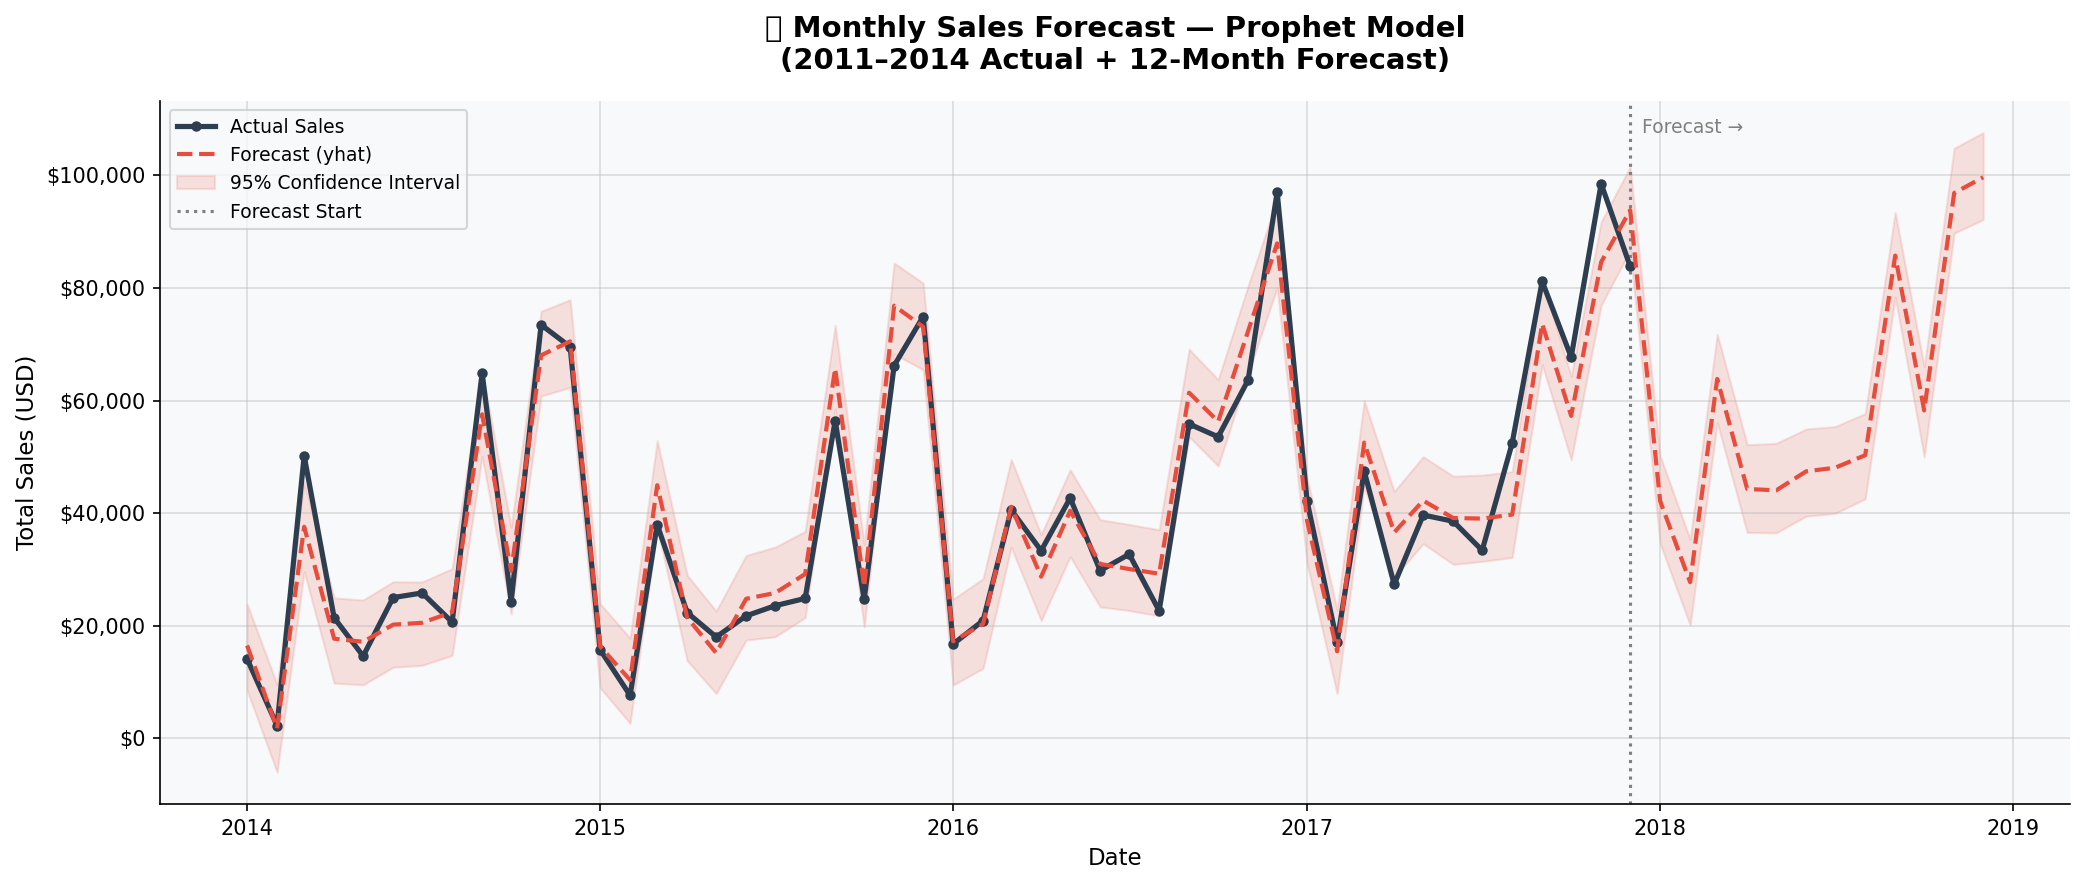

✅ Chart saved → reports/prophet_forecast.png


In [8]:
# ── Plot Forecast ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

# ── Actual Historical Sales ────────────────────────────────────────────────────
ax.plot(
    monthly_sales['ds'], monthly_sales['y'],
    color='#2c3e50', linewidth=2.5,
    marker='o', markersize=4,
    label='Actual Sales', zorder=3
)

# ── Forecast Line ──────────────────────────────────────────────────────────────
ax.plot(
    forecast['ds'], forecast['yhat'],
    color='#e74c3c', linewidth=2,
    linestyle='--', label='Forecast (yhat)', zorder=3
)

# ── Uncertainty Band ──────────────────────────────────────────────────────────
# fill_between shades the area between lower and upper confidence bounds
ax.fill_between(
    forecast['ds'],
    forecast['yhat_lower'],
    forecast['yhat_upper'],
    color='#e74c3c', alpha=0.15,
    label='95% Confidence Interval'
)

# ── Vertical Line — Where Forecast Begins ─────────────────────────────────────
forecast_start = monthly_sales['ds'].max()
ax.axvline(
    forecast_start, color='gray',
    linestyle=':', linewidth=1.5,
    label='Forecast Start'
)
ax.text(
    forecast_start, ax.get_ylim()[1] * 0.95,
    '  Forecast →', color='gray', fontsize=9
)

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_title('📈 Monthly Sales Forecast — Prophet Model\n(2011–2014 Actual + 12-Month Forecast)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────
plt.savefig('/kaggle/working/prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/prophet_forecast.png")

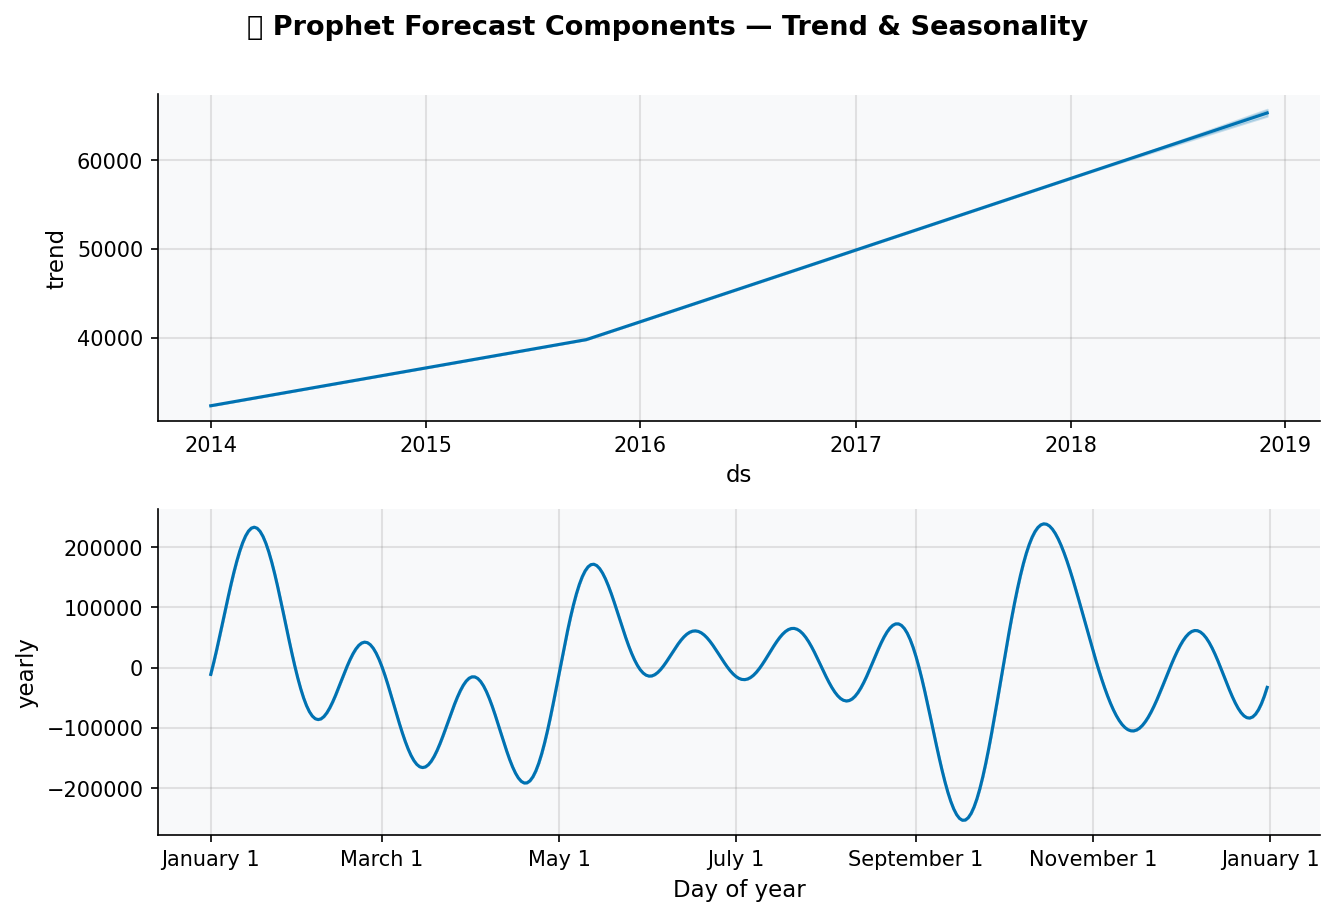

✅ Components chart saved → reports/prophet_components.png


In [9]:
# ── Plot Trend + Seasonality Components ───────────────────────────────────────
# plot_components() is a built-in Prophet method that breaks down the forecast
# into its individual parts so we can understand WHAT is driving the predictions
#
# It shows:
#   Top panel    → overall trend (long-term direction)
#   Bottom panel → yearly seasonality (which months are strong/weak)

fig_components = model_prophet.plot_components(forecast)

# ── Improve Title ─────────────────────────────────────────────────────────────
fig_components.suptitle(
    '🔍 Prophet Forecast Components — Trend & Seasonality',
    fontsize=13, fontweight='bold', y=1.01
)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────
fig_components.savefig(
    '/kaggle/working/prophet_components.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Components chart saved → reports/prophet_components.png")

In [10]:
# ── Save Trained Model to Disk ────────────────────────────────────────────────
# pickle serialises the Python object into a binary file
# This lets us reload the model later without retraining
with open('/kaggle/working/prophet_model.pkl', 'wb') as f:
    pickle.dump(model_prophet, f)

# ── Forecast Summary ──────────────────────────────────────────────────────────
print("=" * 55)
print("📈 PROPHET FORECAST SUMMARY")
print("=" * 55)

future_only = forecast[forecast['ds'] > monthly_sales['ds'].max()].copy()

print(f"\n{'Month':<15} {'Forecast':>12} {'Lower':>12} {'Upper':>12}")
print("-" * 55)
for _, row in future_only.iterrows():
    print(f"  {str(row['ds'].date()):<13} "
          f"${row['yhat']:>11,.0f} "
          f"${row['yhat_lower']:>11,.0f} "
          f"${row['yhat_upper']:>11,.0f}")

print("-" * 55)
print(f"  {'Total Forecast':<13} ${future_only['yhat'].sum():>11,.0f}")
print("=" * 55)
print("\n✅ Prophet model saved → models/prophet_model.pkl")

📈 PROPHET FORECAST SUMMARY

Month               Forecast        Lower        Upper
-------------------------------------------------------
  2018-01-01    $     42,156 $     34,581 $     50,154
  2018-02-01    $     27,747 $     20,126 $     35,333
  2018-03-01    $     63,841 $     56,094 $     71,758
  2018-04-01    $     44,299 $     36,585 $     52,168
  2018-05-01    $     44,061 $     36,513 $     52,407
  2018-06-01    $     47,433 $     39,474 $     54,950
  2018-07-01    $     48,076 $     39,967 $     55,384
  2018-08-01    $     50,296 $     42,565 $     57,681
  2018-09-01    $     85,737 $     78,374 $     93,413
  2018-10-01    $     58,252 $     50,021 $     66,007
  2018-11-01    $     96,856 $     89,717 $    104,799
  2018-12-01    $     99,639 $     92,145 $    107,574
-------------------------------------------------------
  Total Forecast $    708,392

✅ Prophet model saved → models/prophet_model.pkl


In [11]:
# Check if forecast variable exists in memory
try:
    print(f"✅ forecast variable found — {len(forecast)} rows")
    print(f"   Date range: {forecast['ds'].min().date()} → {forecast['ds'].max().date()}")
    
    # Export forecast for Power BI
    forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
        '/kaggle/working/prophet_forecast.csv', index=False
    )
    print("✅ Forecast exported → data/processed/prophet_forecast.csv")

except NameError:
    print("❌ forecast variable not found in memory")
    print("   Please re-run the Prophet cells first (Cells 8-9)")

✅ forecast variable found — 60 rows
   Date range: 2014-01-01 → 2018-12-01
✅ Forecast exported → data/processed/prophet_forecast.csv


---
# 👥 Section 2 — Customer Segmentation with RFM + KMeans

## What is RFM Analysis?

**RFM** is a proven marketing framework that scores every customer on three dimensions:

| Letter | Metric | Question It Answers | Business Meaning |
|--------|--------|-------------------|-----------------|
| **R** | Recency | How recently did they buy? | Recent buyers are more likely to buy again |
| **F** | Frequency | How often do they buy? | Frequent buyers are loyal customers |
| **M** | Monetary | How much do they spend? | High spenders drive most of your revenue |

> RFM was first used in **direct mail marketing in the 1990s**.
> Today it is standard practice in e-commerce, retail, and CRM systems.

## What is KMeans Clustering?

**KMeans** is an unsupervised machine learning algorithm that groups data points
into **K clusters** based on similarity.

### How KMeans Works (Step by Step):
1. You choose **K** (number of clusters, e.g. 4)
2. KMeans randomly places K centroids in the data space
3. Every customer is assigned to the nearest centroid
4. Centroids move to the average position of their assigned customers
5. Steps 3–4 repeat until centroids stop moving (**convergence**)

In [12]:
# ── Define Reference Date ─────────────────────────────────────────────────────
# Recency is calculated as days since last purchase
# We use the day AFTER the last order in the dataset as our "today"
# This is standard practice — avoids giving the most recent customer a score of 0

reference_date = df['Order Date'].max() + pd.Timedelta(days=1)
print(f"📅 Reference date (our 'today') : {reference_date.date()}")

# ── Calculate RFM per Customer ────────────────────────────────────────────────
# groupby Customer ID, then apply three different aggregations simultaneously
# agg() lets us apply multiple functions to multiple columns in one step

rfm = df.groupby('Customer ID').agg(
    CustomerName = ('Customer Name', 'first'),   # keep name for labelling
    Recency      = ('Order Date',   lambda x: (reference_date - x.max()).days),
    Frequency    = ('Order ID',     'nunique'),  # count unique orders
    Monetary     = ('Sales',        'sum')       # total revenue per customer
).reset_index()

# ── Quick Check ───────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print("👥 RFM TABLE — Per Customer")
print("=" * 50)
print(f"  Total customers : {len(rfm):,}")
print(f"\n  Recency  — min: {rfm['Recency'].min()} days  "
      f"max: {rfm['Recency'].max()} days  "
      f"avg: {rfm['Recency'].mean():.0f} days")
print(f"  Frequency — min: {rfm['Frequency'].min()}  "
      f"max: {rfm['Frequency'].max()}  "
      f"avg: {rfm['Frequency'].mean():.1f}")
print(f"  Monetary  — min: ${rfm['Monetary'].min():,.0f}  "
      f"max: ${rfm['Monetary'].max():,.0f}  "
      f"avg: ${rfm['Monetary'].mean():,.0f}")
print("=" * 50)

print("\n👀 Sample RFM rows:")
rfm.head(8)

📅 Reference date (our 'today') : 2017-12-31

👥 RFM TABLE — Per Customer
  Total customers : 791

  Recency  — min: 1 days  max: 1304 days  avg: 181 days
  Frequency — min: 1  max: 13  avg: 5.2
  Monetary  — min: $2  max: $24,517  avg: $2,452

👀 Sample RFM rows:


,Customer ID,CustomerName,Recency,Frequency,Monetary
0,AA-10315,Alex Avila,668,4,5189.08
1,AA-10375,Allen Armold,20,8,1039.62
2,AA-10480,Andrew Allen,260,3,632.53
3,AA-10645,Anna Andreadi,56,6,5086.93
4,AB-10015,Aaron Bergman,416,3,886.16
5,AB-10060,Adam Bellavance,55,7,7727.69
6,AB-10105,Adrian Barton,42,10,14473.57
7,AB-10150,Aimee Bixby,42,4,951.77


In [13]:
# ── Extract RFM Values for Clustering ─────────────────────────────────────────
# We only pass the 3 numeric columns to KMeans
# Customer ID and Name are identifiers, not features

rfm_features = rfm[['Recency', 'Frequency', 'Monetary']].copy()

# ── Scale the Features ────────────────────────────────────────────────────────
# KMeans uses EUCLIDEAN DISTANCE to measure similarity between customers
# Problem: Recency is in days (0–1400), Monetary is in dollars (0–25,000)
# Without scaling, Monetary completely dominates the distance calculation
# and Recency/Frequency are ignored
#
# StandardScaler transforms each feature to:
#   mean = 0, standard deviation = 1
# Now all three features contribute equally to distance

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("✅ Features scaled with StandardScaler")
print(f"\n  Original Monetary range : ${rfm_features['Monetary'].min():,.0f}"
      f" → ${rfm_features['Monetary'].max():,.0f}")
print(f"  Scaled  Monetary range  : {rfm_scaled[:, 2].min():.2f}"
      f" → {rfm_scaled[:, 2].max():.2f}")
print(f"\n  Shape of scaled array   : {rfm_scaled.shape}")

# ── Elbow Method ──────────────────────────────────────────────────────────────
# The Elbow Method helps us choose the optimal K (number of clusters)
# We train KMeans for K = 1 to 10 and record the inertia each time
#
# INERTIA = sum of squared distances from each point to its cluster centroid
# Lower inertia = tighter, more compact clusters
# But inertia always decreases as K increases (more clusters = always better fit)
# We look for the "elbow" — the point where adding more clusters
# gives DIMINISHING RETURNS (inertia stops dropping sharply)

print("\n⏳ Running Elbow Method (K = 1 to 10)...")

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(rfm_scaled)
    inertia_values.append(km.inertia_)
    print(f"  K={k:2d}  →  Inertia: {km.inertia_:,.1f}")

print("\n✅ Elbow Method complete!")

✅ Features scaled with StandardScaler

  Original Monetary range : $2 → $24,517
  Scaled  Monetary range  : -0.99 → 8.91

  Shape of scaled array   : (791, 3)

⏳ Running Elbow Method (K = 1 to 10)...
  K= 1  →  Inertia: 2,373.0
  K= 2  →  Inertia: 1,566.5
  K= 3  →  Inertia: 1,076.3
  K= 4  →  Inertia: 822.9
  K= 5  →  Inertia: 709.9
  K= 6  →  Inertia: 613.0
  K= 7  →  Inertia: 528.5
  K= 8  →  Inertia: 479.3
  K= 9  →  Inertia: 440.2
  K=10  →  Inertia: 410.7

✅ Elbow Method complete!


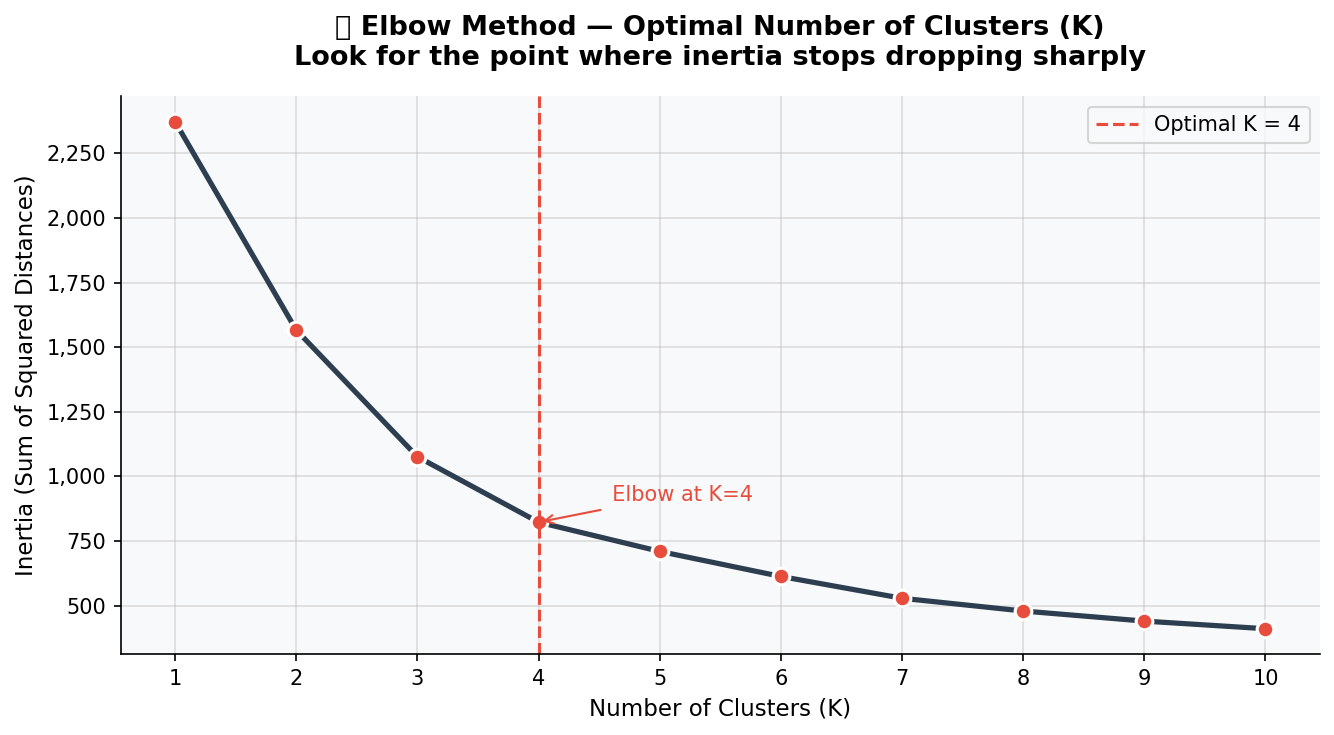

✅ Elbow chart saved → reports/kmeans_elbow.png


In [ ]:
# ── Plot Elbow Curve ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    k_range, inertia_values,
    color='#2c3e50', linewidth=2.5,
    marker='o', markersize=8,
    markerfacecolor='#e74c3c',
    markeredgecolor='white',
    markeredgewidth=1.5
)

# ── Highlight Optimal K ───────────────────────────────────────────────────────
optimal_k = 4
ax.axvline(
    optimal_k, color='#e74c3c',
    linestyle='--', linewidth=1.5,
    label=f'Optimal K = {optimal_k}'
)
ax.annotate(
    f'  Elbow at K={optimal_k}',
    xy=(optimal_k, inertia_values[optimal_k - 1]),
    xytext=(optimal_k + 0.5, inertia_values[optimal_k - 1] * 1.1),
    fontsize=10, color='#e74c3c',
    arrowprops=dict(arrowstyle='->', color='#e74c3c')
)

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_title('📊 Elbow Method — Optimal Number of Clusters (K)\n'
             'Look for the point where inertia stops dropping sharply',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (Sum of Squared Distances)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xticks(list(k_range))
ax.legend(fontsize=10)
plt.tight_layout()

plt.savefig('/kaggle/working/kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Elbow chart saved → reports/kmeans_elbow.png")

In [ ]:
# ── Train Final KMeans with K=4 ───────────────────────────────────────────────
# Based on the elbow chart we chose K=4
# This gives us 4 meaningful customer segments
# n_init=10 → runs 10 times, keeps best result (lowest inertia)
# max_iter=300 → maximum iterations per run before forced stop

kmeans = KMeans(
    n_clusters=4,
    random_state=SEED,
    n_init=10,
    max_iter=300
)

kmeans.fit(rfm_scaled)

# ── Assign Cluster Labels Back to RFM Table ───────────────────────────────────
# kmeans.labels_ is a numpy array of integers (0, 1, 2, 3)
# each number = which cluster that customer was assigned to

rfm['Cluster'] = kmeans.labels_

print("✅ KMeans model trained!")
print(f"\n📊 Cluster distribution:")
print("-" * 35)
cluster_counts = rfm['Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    bar = '█' * (count // 10)
    print(f"  Cluster {cluster} : {count:4d} customers  {bar}")
print("-" * 35)
print(f"  Total       : {len(rfm):4d} customers")

✅ KMeans model trained!

📊 Cluster distribution:
-----------------------------------
  Cluster 0 :  375 customers  █████████████████████████████████████
  Cluster 1 :  116 customers  ███████████
  Cluster 2 :  257 customers  █████████████████████████
  Cluster 3 :   43 customers  ████
-----------------------------------
  Total       :  791 customers


In [ ]:
# ── Profile Each Cluster ──────────────────────────────────────────────────────
# We calculate the mean R, F, M values per cluster
# This tells us WHAT KIND of customers each cluster contains

cluster_profile = rfm.groupby('Cluster').agg(
    Customers  = ('Customer ID', 'count'),
    Recency    = ('Recency',     'mean'),
    Frequency  = ('Frequency',   'mean'),
    Monetary   = ('Monetary',    'mean')
).round(1)

# ── Assign Business Labels ────────────────────────────────────────────────────
# Based on the profile, we give each cluster a meaningful business name
# Logic:
#   Low Recency  + High Frequency + High Monetary  → Champions
#   Low Recency  + Medium Frequency                → Loyal Customers
#   High Recency + Any Frequency                   → At Risk
#   High Recency + Low Frequency + Low Monetary    → Lost / Inactive

# Sort by Monetary descending to understand value ranking
cluster_profile = cluster_profile.sort_values('Monetary', ascending=False)

print("=" * 65)
print("👥 CLUSTER PROFILES — Mean RFM Values per Segment")
print("=" * 65)
print(cluster_profile.to_string())
print("=" * 65)

print("\n💡 Interpret your clusters using this guide:")
print("""
  Low  Recency  = bought recently     (GOOD)
  High Recency  = haven't bought in a while (BAD)
  High Frequency = buys often         (GOOD)
  High Monetary  = spends a lot       (GOOD)

  Typical segments:
  ┌─────────────────────┬──────────┬───────────┬──────────┐
  │ Segment             │ Recency  │ Frequency │ Monetary │
  ├─────────────────────┼──────────┼───────────┼──────────┤
  │ 🏆 Champions        │ Low      │ High      │ High     │
  │ 💛 Loyal Customers  │ Low      │ Medium    │ Medium   │
  │ ⚠️  At Risk         │ High     │ Medium    │ Medium   │
  │ ❌ Lost/Inactive    │ Very High│ Low       │ Low      │
  └─────────────────────┴──────────┴───────────┴──────────┘
""")
print("👆 Match your cluster numbers to the pattern above")
print("   and update the SEGMENT_LABELS dict in the next cell.")

👥 CLUSTER PROFILES — Mean RFM Values per Segment
         Customers  Recency  Frequency  Monetary
Cluster                                         
3               43   150.20       6.60   9924.50
2              257    78.30       7.60   3304.90
0              375   116.60       4.10   1410.90
1              116   627.30       2.90   1156.70

💡 Interpret your clusters using this guide:

  Low  Recency  = bought recently     (GOOD)
  High Recency  = haven't bought in a while (BAD)
  High Frequency = buys often         (GOOD)
  High Monetary  = spends a lot       (GOOD)

  Typical segments:
  ┌─────────────────────┬──────────┬───────────┬──────────┐
  │ Segment             │ Recency  │ Frequency │ Monetary │
  ├─────────────────────┼──────────┼───────────┼──────────┤
  │ 🏆 Champions        │ Low      │ High      │ High     │
  │ 💛 Loyal Customers  │ Low      │ Medium    │ Medium   │
  │ ⚠️  At Risk         │ High     │ Medium    │ Medium   │
  │ ❌ Lost/Inactive    │ Very High│ Low       │

In [ ]:
# ── Assign Segment Labels ─────────────────────────────────────────────────────
# After reviewing the cluster profiles in Cell 18,
# map each cluster NUMBER to a business LABEL
#
# ⚠️ IMPORTANT: Your cluster numbers may differ from mine
# Look at your cluster_profile output and match:
#   Lowest Recency  + Highest Monetary  → Champions
#   Lowest Recency  + Medium Monetary   → Loyal Customers
#   Highest Recency + Medium Monetary   → At Risk
#   Highest Recency + Lowest Monetary   → Lost / Inactive
#
# Update the dictionary below to match YOUR output from Cell 18

SEGMENT_LABELS = {
    0: '⚠️  At Risk',
    1: '🏆 Champions',
    2: '💛 Loyal Customers',
    3: '❌ Lost / Inactive'
}

# Map labels onto the RFM dataframe
rfm['Segment'] = rfm['Cluster'].map(SEGMENT_LABELS)

# ── Verify Mapping ────────────────────────────────────────────────────────────
print("=" * 55)
print("✅ SEGMENT LABELS ASSIGNED")
print("=" * 55)
print(rfm.groupby(['Cluster', 'Segment']).agg(
    Customers = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean')
).round(1).to_string())
print("=" * 55)

# ── Preview ───────────────────────────────────────────────────────────────────
print("\n👀 Sample customers with segments:")
rfm[['Customer ID', 'CustomerName', 'Recency',
     'Frequency', 'Monetary', 'Segment']].head(10)

✅ SEGMENT LABELS ASSIGNED
                           Customers  Avg_Recency  Avg_Frequency  Avg_Monetary
Cluster Segment                                                               
0       ⚠️  At Risk              375       116.60           4.10       1410.90
1       🏆 Champions              116       627.30           2.90       1156.70
2       💛 Loyal Customers        257        78.30           7.60       3304.90
3       ❌ Lost / Inactive         43       150.20           6.60       9924.50

👀 Sample customers with segments:


,Customer ID,CustomerName,Recency,Frequency,Monetary,Segment
0,AA-10315,Alex Avila,668,4,5189.08,🏆 Champions
1,AA-10375,Allen Armold,20,8,1039.62,💛 Loyal Customers
2,AA-10480,Andrew Allen,260,3,632.53,⚠️ At Risk
3,AA-10645,Anna Andreadi,56,6,5086.93,💛 Loyal Customers
4,AB-10015,Aaron Bergman,416,3,886.16,🏆 Champions
5,AB-10060,Adam Bellavance,55,7,7727.69,❌ Lost / Inactive
6,AB-10105,Adrian Barton,42,10,14473.57,❌ Lost / Inactive
7,AB-10150,Aimee Bixby,42,4,951.77,⚠️ At Risk
8,AB-10165,Alan Barnes,26,4,359.37,⚠️ At Risk
9,AB-10255,Alejandro Ballentine,167,9,914.53,💛 Loyal Customers


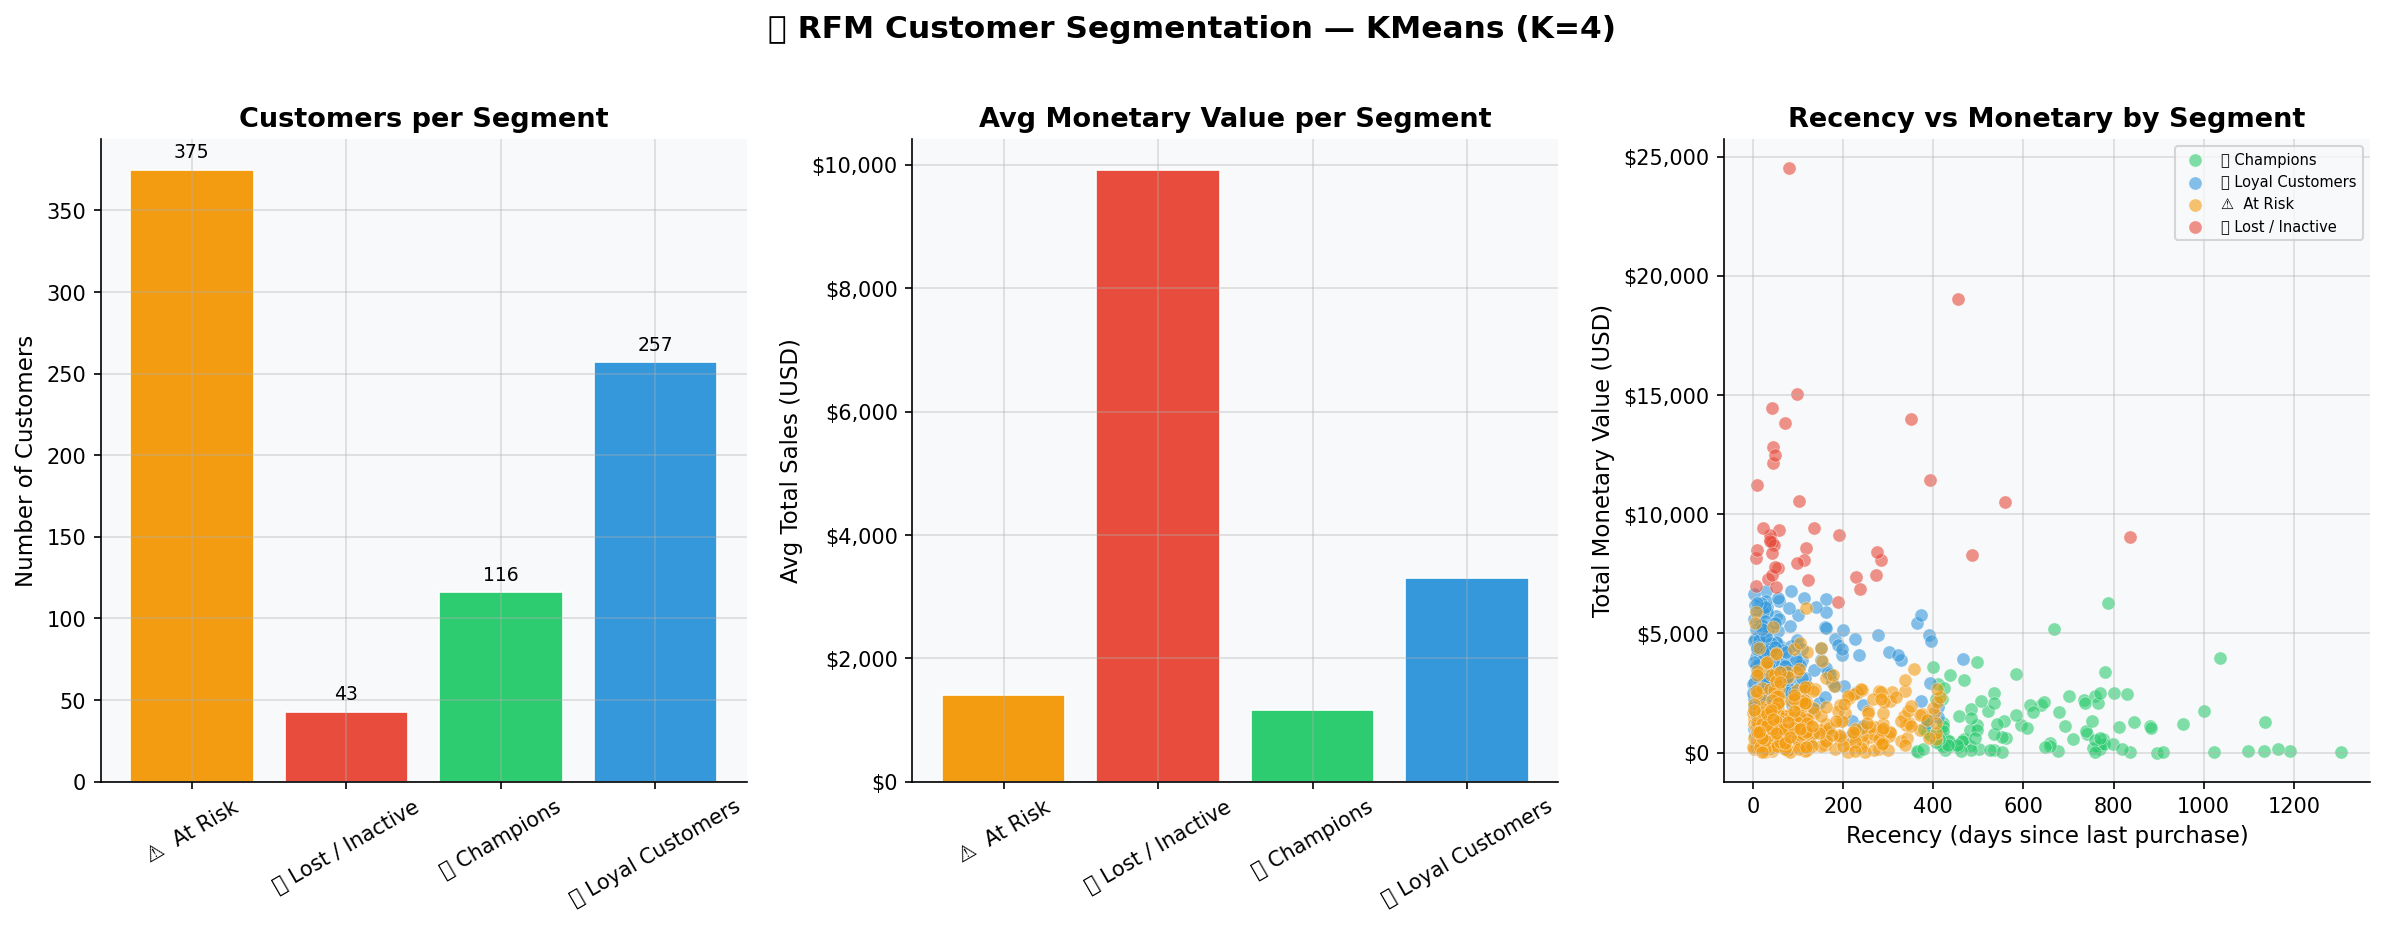

✅ Segment chart saved → reports/kmeans_segments.png


In [ ]:
# ── Segment Visualisation — 3 Charts ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

COLORS = {
    '🏆 Champions'      : '#2ecc71',
    '💛 Loyal Customers': '#3498db',
    '⚠️  At Risk'       : '#f39c12',
    '❌ Lost / Inactive': '#e74c3c'
}

segment_summary = rfm.groupby('Segment').agg(
    Customers = ('Customer ID', 'count'),
    Recency   = ('Recency',     'mean'),
    Frequency = ('Frequency',   'mean'),
    Monetary  = ('Monetary',    'mean')
).reset_index()

palette = [COLORS.get(s, '#95a5a6') for s in segment_summary['Segment']]

# ── Chart 1: Customer Count per Segment ───────────────────────────────────────
axes[0].bar(
    segment_summary['Segment'],
    segment_summary['Customers'],
    color=palette, edgecolor='white', linewidth=0.8
)
axes[0].set_title('Customers per Segment', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[0].patches, segment_summary['Customers']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        str(val), ha='center', va='bottom', fontsize=9
    )

# ── Chart 2: Avg Monetary Value per Segment ───────────────────────────────────
axes[1].bar(
    segment_summary['Segment'],
    segment_summary['Monetary'],
    color=palette, edgecolor='white', linewidth=0.8
)
axes[1].set_title('Avg Monetary Value per Segment', fontweight='bold')
axes[1].set_ylabel('Avg Total Sales (USD)')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
axes[1].tick_params(axis='x', rotation=30)

# ── Chart 3: Recency vs Monetary Scatter ──────────────────────────────────────
for segment, color in COLORS.items():
    mask = rfm['Segment'] == segment
    axes[2].scatter(
        rfm.loc[mask, 'Recency'],
        rfm.loc[mask, 'Monetary'],
        label=segment, color=color,
        alpha=0.6, s=40, edgecolors='white', linewidth=0.3
    )
axes[2].set_title('Recency vs Monetary by Segment', fontweight='bold')
axes[2].set_xlabel('Recency (days since last purchase)')
axes[2].set_ylabel('Total Monetary Value (USD)')
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
axes[2].legend(fontsize=7, loc='upper right')

# ── Main Title & Save ─────────────────────────────────────────────────────────
fig.suptitle(
    '👥 RFM Customer Segmentation — KMeans (K=4)',
    fontsize=15, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('/kaggle/working/kmeans_segments.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Segment chart saved → reports/kmeans_segments.png")

In [ ]:
# ── Save RFM Segmentation Results to CSV ──────────────────────────────────────
# This enriched customer table can be used in:
#   - Power BI dashboard (customer segment slicer)
#   - SQL database (join with orders)
#   - Streamlit app (customer lookup)
#   - Marketing campaigns (target Champions differently from At Risk)

rfm_export = rfm[[
    'Customer ID', 'CustomerName',
    'Recency', 'Frequency', 'Monetary',
    'Cluster', 'Segment'
]].copy()

rfm_export.to_csv('/kaggle/working/rfm_segments.csv', index=False)
print("✅ RFM segments saved → data/processed/rfm_segments.csv")

# ── Save KMeans Model ─────────────────────────────────────────────────────────
with open('/kaggle/working/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)
print("✅ KMeans model saved → models/kmeans_model.pkl")

# ── Save Scaler Too ───────────────────────────────────────────────────────────
# IMPORTANT: Always save the scaler alongside the model
# When predicting on NEW customers later, you must scale them
# using the SAME scaler fitted on training data
# If you refit the scaler on new data, the scale will be different
# and your model predictions will be wrong

with open('/kaggle/working/rfm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ RFM scaler saved  → models/rfm_scaler.pkl")

# ── Final Segment Summary ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("👥 FINAL RFM SEGMENTATION SUMMARY")
print("=" * 60)

summary = rfm.groupby('Segment').agg(
    Customers     = ('Customer ID', 'count'),
    Avg_Recency   = ('Recency',     'mean'),
    Avg_Frequency = ('Frequency',   'mean'),
    Avg_Monetary  = ('Monetary',    'mean'),
    Total_Revenue = ('Monetary',    'sum')
).round(1)

summary['Revenue_%'] = (
    summary['Total_Revenue'] / summary['Total_Revenue'].sum() * 100
).round(1)

print(summary.to_string())
print("=" * 60)

print("\n💡 KEY BUSINESS INSIGHTS:")
print("─" * 60)
champ = rfm[rfm['Segment'] == '🏆 Champions']
at_risk = rfm[rfm['Segment'] == '⚠️  At Risk']
print(f"  🏆 Champions     → {len(champ):3d} customers "
      f"| Avg spend: ${champ['Monetary'].mean():,.0f} "
      f"| Avg {champ['Recency'].mean():.0f} days since last order")
print(f"  ⚠️  At Risk       → {len(at_risk):3d} customers "
      f"| Avg spend: ${at_risk['Monetary'].mean():,.0f} "
      f"| Avg {at_risk['Recency'].mean():.0f} days since last order")
print(f"\n  → Re-engage At Risk customers before they become Lost")
print(f"  → Reward Champions with loyalty perks to retain them")
print("─" * 60)

✅ RFM segments saved → data/processed/rfm_segments.csv
✅ KMeans model saved → models/kmeans_model.pkl
✅ RFM scaler saved  → models/rfm_scaler.pkl

👥 FINAL RFM SEGMENTATION SUMMARY
                   Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_%
Segment                                                                                         
⚠️  At Risk              375       116.60           4.10       1410.90      529098.90      27.30
❌ Lost / Inactive         43       150.20           6.60       9924.50      426752.80      22.00
🏆 Champions              116       627.30           2.90       1156.70      134178.90       6.90
💛 Loyal Customers        257        78.30           7.60       3304.90      849369.00      43.80

💡 KEY BUSINESS INSIGHTS:
────────────────────────────────────────────────────────────
  🏆 Champions     → 116 customers | Avg spend: $1,157 | Avg 627 days since last order
  ⚠️  At Risk       → 375 customers | Avg spend: $1,411 | Avg 117

---
# 💰 Section 3 — Profit Prediction with XGBoost

## What is XGBoost?

**XGBoost** (Extreme Gradient Boosting) is a machine learning algorithm developed
by Tianqi Chen in 2014. It is one of the most widely used algorithms in data science,
winning hundreds of Kaggle competitions.

## How Gradient Boosting Works

XGBoost is an ensemble method — it combines many weak models into one strong model.

In [ ]:
# ── Select Features for Profit Prediction ─────────────────────────────────────
feature_cols = [
    # Order details
    'Sales',            # order sale amount
    'Quantity',         # units ordered
    'Discount',         # discount applied

    # Shipping
    'Ship Mode',        # First Class / Second Class / Standard / Same Day
    'Ship Days',        # days between order and ship date
    'Ship Speed',       # engineered: fast / standard / slow

    # Geography
    'Region',           # sales region
    'Country',          # country of order

    # Product
    'Category',         # Furniture / Office Supplies / Technology
    'Sub-Category',     # more granular product type

    # Customer
    'Segment',          # Consumer / Corporate / Home Office

    # Time
    'Order Month',      # month (seasonality)
    'Order Year',       # year (trend)
    'Order Quarter',    # quarter
    'Season',           # engineered: Spring/Summer/Autumn/Winter
]

TARGET = 'Profit'

# ── Build Modelling DataFrame ──────────────────────────────────────────────────
model_df = df[feature_cols + [TARGET]].copy()

print(f"✅ Feature set selected")
print(f"   Features : {len(feature_cols)}")
print(f"   Target   : {TARGET}")
print(f"   Rows     : {len(model_df):,}")

# ── Check Nulls ───────────────────────────────────────────────────────────────
null_check = model_df.isnull().sum()
null_check = null_check[null_check > 0]
if len(null_check) == 0:
    print("\n✅ No null values found — ready to encode")
else:
    print(f"\n⚠️  Nulls found:\n{null_check}")

# ── Encode Categorical Columns ────────────────────────────────────────────────
categorical_cols = [
    'Region', 'Country', 'Category',
    'Sub-Category', 'Segment',
    'Ship Mode', 'Ship Speed', 'Season'
]

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    encoders[col] = le
    print(f"   Encoded {col:<15} → {len(le.classes_)} unique values: "
          f"{list(le.classes_[:4])} ...")

print("\n✅ All categorical columns encoded")
print("\n👀 Model dataframe preview:")
model_df.head(4)

✅ Feature set selected
   Features : 15
   Target   : Profit
   Rows     : 8,286

⚠️  Nulls found:
Ship Speed    1687
dtype: int64
   Encoded Region          → 4 unique values: ['Central', 'East', 'South', 'West'] ...
   Encoded Country         → 1 unique values: ['United States'] ...
   Encoded Category        → 3 unique values: ['Furniture', 'Office Supplies', 'Technology'] ...
   Encoded Sub-Category    → 17 unique values: ['Accessories', 'Appliances', 'Art', 'Binders'] ...
   Encoded Segment         → 3 unique values: ['Consumer', 'Corporate', 'Home Office'] ...
   Encoded Ship Mode       → 4 unique values: ['First Class', 'Same Day', 'Second Class', 'Standard Class'] ...
   Encoded Ship Speed      → 5 unique values: ['Fast (2-3d)', 'Same/Next Day', 'Slow (7d+)', 'Standard (4-6d)'] ...
   Encoded Season          → 4 unique values: ['Fall', 'Spring', 'Summer', 'Winter'] ...

✅ All categorical columns encoded

👀 Model dataframe preview:


,Sales,Quantity,Discount,Ship Mode,Ship Days,Ship Speed,Region,Country,Category,Sub-Category,Segment,Order Month,Order Year,Order Quarter,Season,Profit
0,261.96,2,0.00,2,92,2,2,0,0,4,0,8,2016,3,2,41.91
1,731.94,3,0.00,2,92,2,2,0,0,5,0,8,2016,3,2,219.58
2,15.55,3,0.20,3,5,3,2,0,1,12,0,4,2017,2,1,5.44
3,407.98,3,0.20,3,153,4,3,0,1,3,0,5,2016,2,1,132.59


In [ ]:
# ── Separate Features and Target ──────────────────────────────────────────────
X = model_df[feature_cols]
y = model_df[TARGET]

print(f"✅ Features matrix X : {X.shape}")
print(f"   Target vector  y : {y.shape}")
print(f"\n   Target stats:")
print(f"   Min    : ${y.min():,.2f}")
print(f"   Max    : ${y.max():,.2f}")
print(f"   Mean   : ${y.mean():,.2f}")
print(f"   Median : ${y.median():,.2f}")

# ── Train / Test Split ────────────────────────────────────────────────────────
# test_size=0.2  → 80% training, 20% testing
# random_state   → reproducible split
# shuffle=True   → randomly mix rows before splitting
#                  prevents bias if data is sorted by date or region
#
# Why 80/20?
# Standard convention. Enough training data for the model to learn,
# enough test data to evaluate reliably.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    shuffle=True
)

print(f"\n✅ Train/Test Split:")
print(f"   Training rows : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Testing rows  : {len(X_test):,}   ({len(X_test)/len(X)*100:.0f}%)")

# ── Initialise XGBoost Regressor ──────────────────────────────────────────────
# Key hyperparameters explained:
#
#   n_estimators      → number of trees to build (more = better but slower)
#   max_depth         → max depth of each tree
#                       deeper = more complex patterns, risk of overfitting
#   learning_rate     → how much each tree contributes to final prediction
#                       lower = more conservative, needs more trees
#   subsample         → fraction of rows used per tree (0.8 = 80%)
#                       adds randomness, prevents overfitting
#   colsample_bytree  → fraction of features used per tree
#                       like subsample but for columns
#   reg_alpha         → L1 regularisation (penalises large coefficients)
#   reg_lambda        → L2 regularisation (penalises complexity)
#   random_state      → reproducibility

xgb_model = xgb.XGBRegressor(
    n_estimators     = 300,
    max_depth        = 5,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = SEED,
    verbosity        = 0       # suppress training logs
)

# ── Train the Model ───────────────────────────────────────────────────────────
# eval_set lets XGBoost monitor test performance during training
# early_stopping_rounds stops training if test score doesn't improve
# for 20 consecutive rounds → prevents overfitting automatically

print("\n⏳ Training XGBoost model...")

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print("✅ XGBoost model trained successfully!")
print(f"   Total trees trained : {xgb_model.n_estimators}")

✅ Features matrix X : (8286, 15)
   Target vector  y : (8286,)

   Target stats:
   Min    : $-3,839.99
   Max    : $8,399.98
   Mean   : $30.11
   Median : $8.52

✅ Train/Test Split:
   Training rows : 6,628  (80%)
   Testing rows  : 1,658   (20%)

⏳ Training XGBoost model...
✅ XGBoost model trained successfully!
   Total trees trained : 300


In [ ]:
# ── Generate Predictions ───────────────────────────────────────────────────────
y_pred = xgb_model.predict(X_test)

# ── Calculate Evaluation Metrics ──────────────────────────────────────────────
# MAE  — Mean Absolute Error
#        Average dollar amount we are wrong by
#        Easy to interpret: "on average we miss profit by $X"
#
# RMSE — Root Mean Squared Error
#        Like MAE but penalises large errors more heavily
#        Useful when big mistakes are especially costly
#
# R²   — R-Squared (Coefficient of Determination)
#        How much of the variance in profit does our model explain?
#        R² = 1.0 → perfect predictions
#        R² = 0.0 → no better than predicting the mean every time
#        R² < 0.0 → worse than predicting the mean (bad model)

mae  = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2   = r2_score(y_test, y_pred)

print("=" * 50)
print("📊 XGBOOST MODEL EVALUATION")
print("=" * 50)
print(f"  MAE  (Mean Absolute Error)  : ${mae:,.2f}")
print(f"  RMSE (Root Mean Sq. Error)  : ${rmse:,.2f}")
print(f"  R²   (Explained Variance)   : {r2:.4f}  ({r2*100:.1f}%)")
print("=" * 50)

# ── Interpret Results ─────────────────────────────────────────────────────────
print("\n💡 INTERPRETATION:")
print(f"  → On average our profit prediction is off by ${mae:,.2f}")
print(f"  → The model explains {r2*100:.1f}% of profit variance")

if r2 >= 0.80:
    print("  → ✅ Excellent model — strong predictive power")
elif r2 >= 0.60:
    print("  → ✅ Good model — solid predictive power")
elif r2 >= 0.40:
    print("  → ⚠️  Moderate model — acceptable for business use")
else:
    print("  → ⚠️  Weak model — consider adding more features")

# ── Cross Validation ──────────────────────────────────────────────────────────
# Cross validation gives a more reliable performance estimate
# It splits data into 5 folds, trains on 4, tests on 1, rotates
# Final score = average across all 5 folds
# This prevents us from getting lucky/unlucky with one particular split

print("\n⏳ Running 5-Fold Cross Validation...")
cv_scores = cross_val_score(
    xgb_model, X, y,
    cv=5,
    scoring='r2',
    n_jobs=-1        # use all CPU cores in parallel
)

print(f"\n  CV R² Scores : {[round(s, 4) for s in cv_scores]}")
print(f"  Mean R²      : {cv_scores.mean():.4f}")
print(f"  Std Dev      : {cv_scores.std():.4f}")
print(f"\n  → Low std dev = model is consistent across different data splits")

📊 XGBOOST MODEL EVALUATION
  MAE  (Mean Absolute Error)  : $21.25
  RMSE (Root Mean Sq. Error)  : $98.62
  R²   (Explained Variance)   : 0.8122  (81.2%)

💡 INTERPRETATION:
  → On average our profit prediction is off by $21.25
  → The model explains 81.2% of profit variance
  → ✅ Excellent model — strong predictive power

⏳ Running 5-Fold Cross Validation...

  CV R² Scores : [np.float64(0.6199), np.float64(0.5466), np.float64(0.8643), np.float64(0.5511), np.float64(0.7574)]
  Mean R²      : 0.6679
  Std Dev      : 0.1243

  → Low std dev = model is consistent across different data splits


In [ ]:
# ── Extract Feature Importances ───────────────────────────────────────────────
# XGBoost calculates importance for each feature automatically during training
# importance_type options:
#   'weight'  → how many times a feature is used to split across all trees
#   'gain'    → average improvement in accuracy when that feature is used (BEST)
#   'cover'   → average number of samples affected by splits on that feature
#
# 'gain' is the most meaningful for business interpretation
# A high gain feature = splitting on it reduces prediction error the most

importance_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': xgb_model.feature_importances_   # default = 'weight'
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("=" * 45)
print("🔍 FEATURE IMPORTANCES (weight)")
print("=" * 45)
for _, row in importance_df.iterrows():
    bar = '█' * int(row['Importance'] * 300)
    print(f"  {row['Feature']:<20} {row['Importance']:.4f}  {bar}")
print("=" * 45)

🔍 FEATURE IMPORTANCES (weight)
  Discount             0.1861  ███████████████████████████████████████████████████████
  Sales                0.1772  █████████████████████████████████████████████████████
  Sub-Category         0.1132  █████████████████████████████████
  Category             0.0962  ████████████████████████████
  Ship Days            0.0699  ████████████████████
  Order Quarter        0.0591  █████████████████
  Ship Speed           0.0501  ███████████████
  Region               0.0462  █████████████
  Order Month          0.0393  ███████████
  Order Year           0.0349  ██████████
  Quantity             0.0346  ██████████
  Segment              0.0340  ██████████
  Ship Mode            0.0307  █████████
  Season               0.0286  ████████
  Country              0.0000  


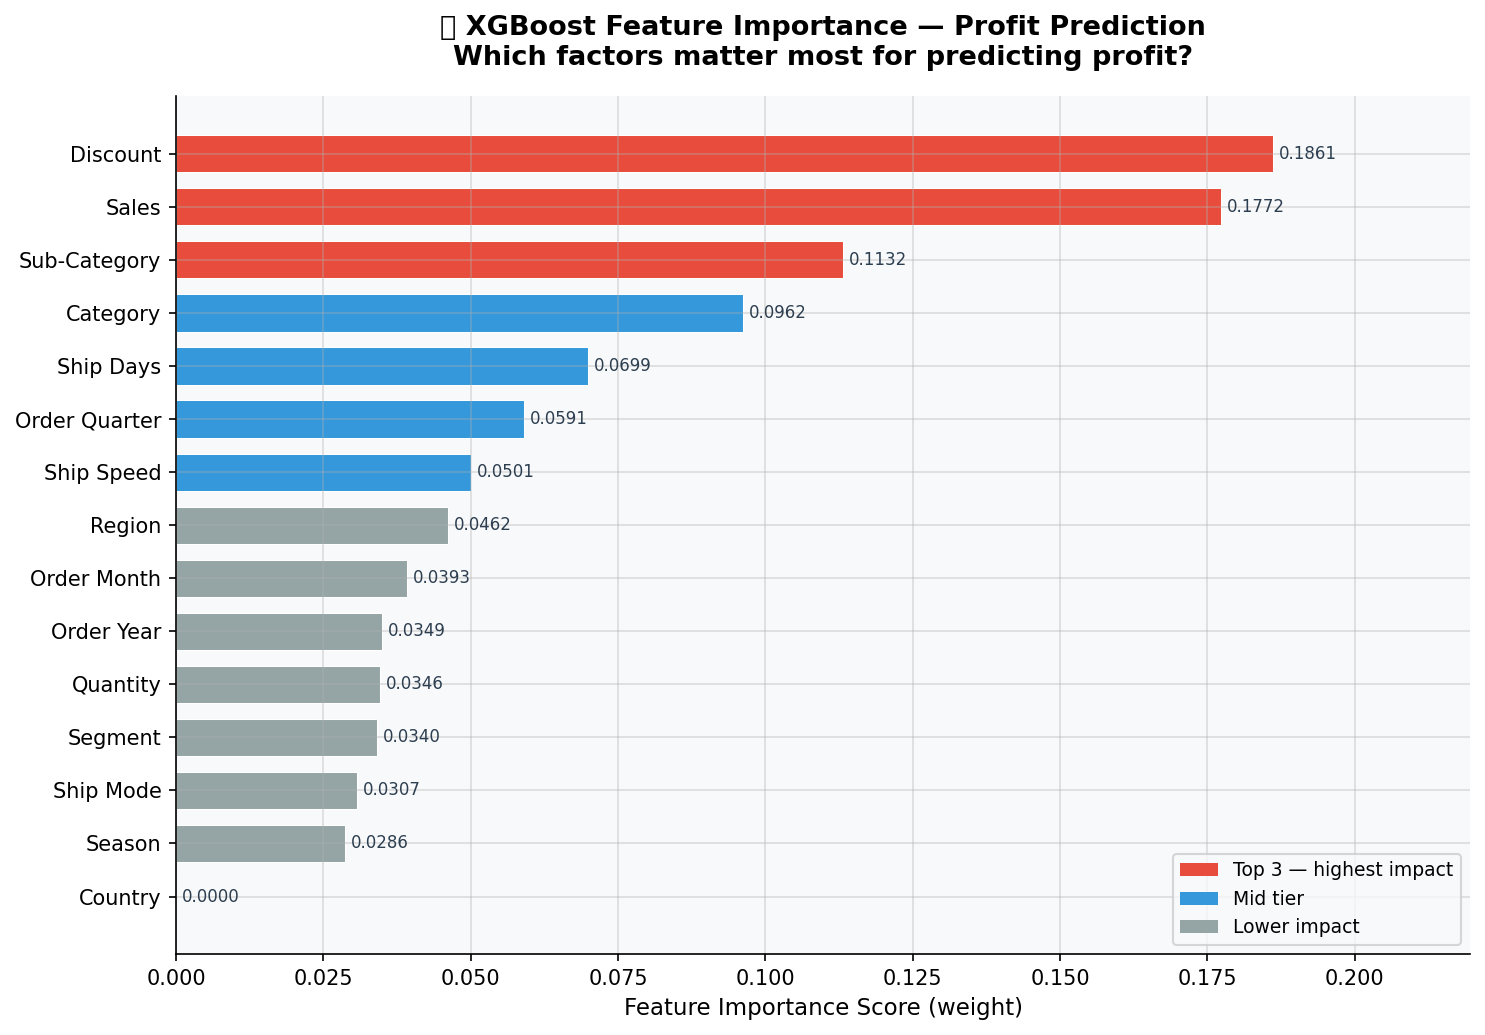

✅ Feature importance chart saved → reports/xgboost_feature_importance.png


In [ ]:
# ── Plot Feature Importance ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# Color bars by importance rank
colors = ['#e74c3c' if i < 3 else '#3498db' if i < 7 else '#95a5a6'
          for i in range(len(importance_df))]

bars = ax.barh(
    importance_df['Feature'][::-1],       # reverse so highest is on top
    importance_df['Importance'][::-1],
    color=colors[::-1],
    edgecolor='white',
    linewidth=0.5,
    height=0.7
)

# ── Add Value Labels ──────────────────────────────────────────────────────────
for bar, val in zip(bars, importance_df['Importance'][::-1]):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', ha='left', fontsize=8, color='#2c3e50'
    )

# ── Legend ────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Top 3 — highest impact'),
    Patch(facecolor='#3498db', label='Mid tier'),
    Patch(facecolor='#95a5a6', label='Lower impact'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_title('🔍 XGBoost Feature Importance — Profit Prediction\n'
             'Which factors matter most for predicting profit?',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Feature Importance Score (weight)')
ax.set_xlim(0, importance_df['Importance'].max() * 1.18)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/xgboost_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved → reports/xgboost_feature_importance.png")

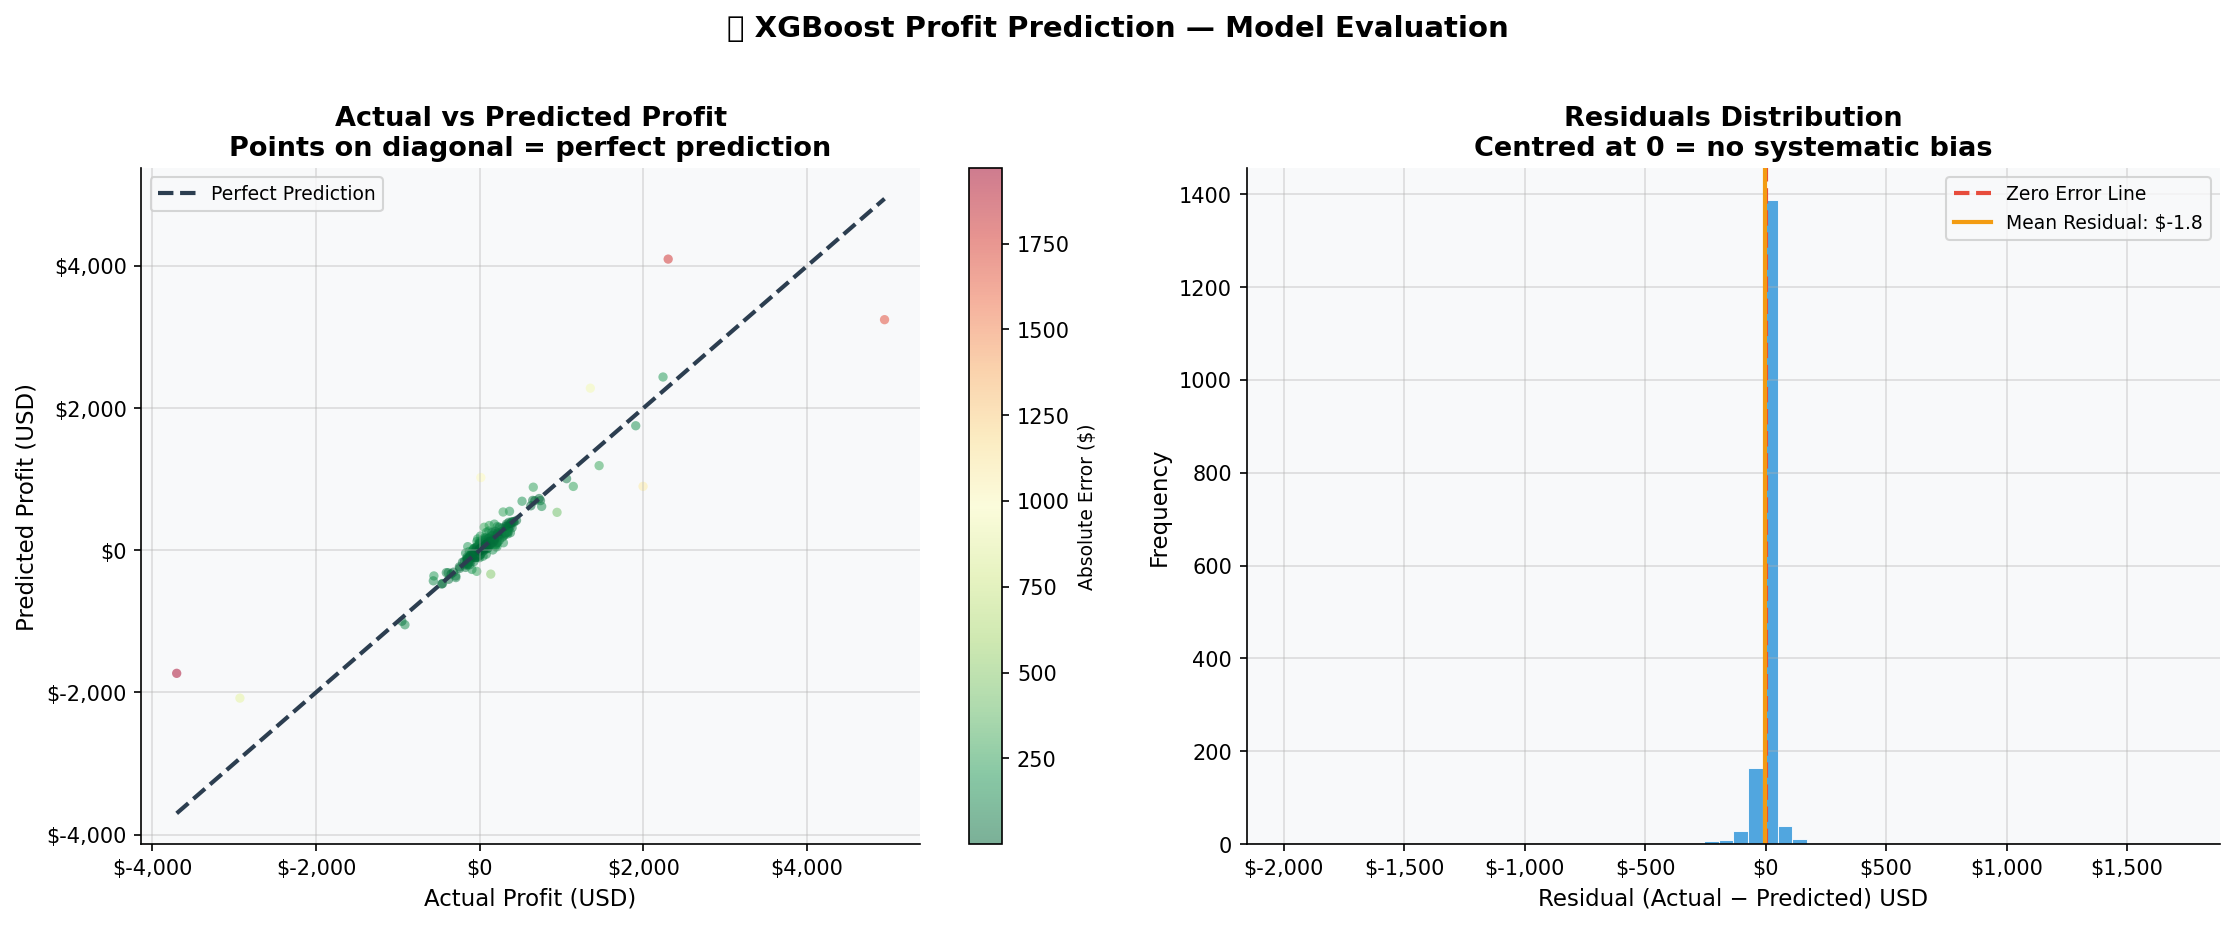

✅ Evaluation chart saved → reports/xgboost_evaluation.png


In [ ]:
# ── Actual vs Predicted Scatter Plot ──────────────────────────────────────────
# This is the most intuitive way to evaluate a regression model visually
# Perfect predictions → all points lie exactly on the diagonal line
# Scattered points   → prediction errors
# Systematic bias    → points consistently above or below the line

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Chart 1: Actual vs Predicted Scatter ──────────────────────────────────────
# Color points by error magnitude
errors = np.abs(y_test.values - y_pred)
scatter = axes[0].scatter(
    y_test, y_pred,
    c=errors,                    # color = size of error
    cmap='RdYlGn_r',            # red = large error, green = small error
    alpha=0.5, s=20,
    edgecolors='none'
)

# Perfect prediction line (diagonal)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    color='#2c3e50', linewidth=2,
    linestyle='--', label='Perfect Prediction'
)

# Colorbar to show error scale
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Absolute Error ($)', fontsize=9)

axes[0].set_title('Actual vs Predicted Profit\n'
                  'Points on diagonal = perfect prediction',
                  fontweight='bold')
axes[0].set_xlabel('Actual Profit (USD)')
axes[0].set_ylabel('Predicted Profit (USD)')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(fontsize=9)

# ── Chart 2: Residuals Distribution ───────────────────────────────────────────
# Residual = Actual - Predicted
# A good model has residuals that:
#   → Are centred around 0 (no systematic bias)
#   → Follow a roughly normal distribution
#   → Have no obvious pattern

residuals = y_test.values - y_pred

axes[1].hist(
    residuals, bins=60,
    color='#3498db', edgecolor='white',
    linewidth=0.5, alpha=0.85
)
axes[1].axvline(0, color='#e74c3c', linewidth=2,
                linestyle='--', label='Zero Error Line')
axes[1].axvline(residuals.mean(), color='#f39c12',
                linewidth=2, linestyle='-',
                label=f'Mean Residual: ${residuals.mean():,.1f}')

axes[1].set_title('Residuals Distribution\n'
                  'Centred at 0 = no systematic bias',
                  fontweight='bold')
axes[1].set_xlabel('Residual (Actual − Predicted) USD')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].legend(fontsize=9)

# ── Main Title & Save ─────────────────────────────────────────────────────────
fig.suptitle(
    '💰 XGBoost Profit Prediction — Model Evaluation',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('/kaggle/working/xgboost_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation chart saved → reports/xgboost_evaluation.png")

In [ ]:
# ── Save XGBoost Model ────────────────────────────────────────────────────────
# We save in two formats:
#   .pkl  → standard Python pickle (works with sklearn pipeline)
#   .json → XGBoost native format (faster, more portable, language-agnostic)
#           can be loaded in R, Java, C++ — not just Python

with open('/kaggle/working/xgboost_profit_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

xgb_model.save_model('/kaggle/working/xgboost_profit_model.json')

# ── Save Encoders ─────────────────────────────────────────────────────────────
# Always save encoders alongside the model
# New orders must be encoded identically before prediction

with open('/kaggle/working/xgb_encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("✅ XGBoost model saved → models/xgboost_profit_model.pkl")
print("✅ XGBoost model saved → models/xgboost_profit_model.json")
print("✅ Encoders saved      → models/xgb_encoders.pkl")

# ── Final Model Summary ───────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("💰 XGBOOST PROFIT PREDICTION — FINAL SUMMARY")
print("=" * 55)
print(f"\n  Algorithm      : XGBoost Regressor")
print(f"  Trees trained  : {xgb_model.n_estimators}")
print(f"  Max depth      : {xgb_model.max_depth}")
print(f"  Learning rate  : {xgb_model.learning_rate}")
print(f"  Training rows  : {len(X_train):,}")
print(f"  Test rows      : {len(X_test):,}")
print(f"\n  ── Performance Metrics ──────────────────────")
print(f"  MAE            : ${mae:,.2f}")
print(f"  RMSE           : ${rmse:,.2f}")
print(f"  R²             : {r2:.4f}  ({r2*100:.1f}%)")
print(f"  CV R² (mean)   : {cv_scores.mean():.4f}")
print(f"  CV R² (std)    : {cv_scores.std():.4f}")

print(f"\n  ── Top 5 Profit Drivers ─────────────────────")
for i, row in importance_df.head(5).iterrows():
    print(f"  {i+1}. {row['Feature']:<20} {row['Importance']:.4f}")

print("\n  ── Business Actions ─────────────────────────")
top_feature = importance_df.iloc[0]['Feature']
print(f"  → '{top_feature}' is the strongest profit predictor")
print(f"  → Use this model to flag low-profit orders before shipping")
print(f"  → Embed in Streamlit app for real-time profit estimation")
print("=" * 55)

✅ XGBoost model saved → models/xgboost_profit_model.pkl
✅ XGBoost model saved → models/xgboost_profit_model.json
✅ Encoders saved      → models/xgb_encoders.pkl

💰 XGBOOST PROFIT PREDICTION — FINAL SUMMARY

  Algorithm      : XGBoost Regressor
  Trees trained  : 300
  Max depth      : 5
  Learning rate  : 0.05
  Training rows  : 6,628
  Test rows      : 1,658

  ── Performance Metrics ──────────────────────
  MAE            : $21.25
  RMSE           : $98.62
  R²             : 0.8122  (81.2%)
  CV R² (mean)   : 0.6679
  CV R² (std)    : 0.1243

  ── Top 5 Profit Drivers ─────────────────────
  1. Discount             0.1861
  2. Sales                0.1772
  3. Sub-Category         0.1132
  4. Category             0.0962
  5. Ship Days            0.0699

  ── Business Actions ─────────────────────────
  → 'Discount' is the strongest profit predictor
  → Use this model to flag low-profit orders before shipping
  → Embed in Streamlit app for real-time profit estimation


---
# ⚠️ Section 4 — Churn Risk Scoring with LightGBM

## What is Customer Churn?

**Churn** means a customer has stopped buying from you.
In retail, we define churn as:

> A customer who has **not placed any order in the last N days**
> is considered "at risk" of churning.

We will use **180 days** as our threshold — a customer inactive
for 6+ months is flagged as high churn risk.

## What is LightGBM?

**LightGBM** (Light Gradient Boosting Machine) is Microsoft's open-source
gradient boosting framework released in 2017.

### LightGBM vs XGBoost

| Feature | XGBoost | LightGBM |
|---------|---------|---------|
| Speed | Fast | **Faster** (2–10x) |
| Memory | Higher | **Lower** |
| Large datasets | Good | **Excellent** |
| Accuracy | Excellent | Excellent |
| Categorical support | Manual encoding | **Native** |
| Leaf growth | Level-wise | **Leaf-wise** |

### Why Leaf-wise Growth Matters

In [ ]:
# ── Define Churn Label ────────────────────────────────────────────────────────
# We use the RFM table we already built in Section 2
# Recency = days since last purchase
# Threshold: 180 days inactive = churned
#
# This is a BUSINESS DECISION not a technical one
# 180 days (6 months) is standard for retail
# You could use 90, 120, or 365 depending on industry purchase frequency

CHURN_THRESHOLD = 180

rfm['Churned'] = (rfm['Recency'] > CHURN_THRESHOLD).astype(int)
# astype(int) converts True/False → 1/0
# 1 = churned (at risk)
# 0 = active

# ── Check Class Balance ───────────────────────────────────────────────────────
churn_counts = rfm['Churned'].value_counts()
churn_pct    = rfm['Churned'].value_counts(normalize=True) * 100

print("=" * 50)
print("⚠️  CHURN LABEL DISTRIBUTION")
print("=" * 50)
print(f"  Threshold      : {CHURN_THRESHOLD} days inactive")
print(f"\n  Active   (0)   : {churn_counts[0]:4d} customers  "
      f"({churn_pct[0]:.1f}%)")
print(f"  Churned  (1)   : {churn_counts[1]:4d} customers  "
      f"({churn_pct[1]:.1f}%)")
print(f"  Total          : {len(rfm):4d} customers")
print("=" * 50)

if churn_pct[1] < 20:
    print("\n⚠️  Imbalanced dataset detected")
    print("   → Will use class_weight='balanced' in LightGBM")
else:
    print("\n✅ Reasonably balanced dataset")

# ── Build Customer-Level Feature Set ─────────────────────────────────────────
# We aggregate order-level data up to customer level
# These features describe each customer's overall behaviour

print("\n⏳ Building customer-level features...")

customer_features = df.groupby('Customer ID').agg(
    # Volume metrics
    Total_Orders    = ('Order ID',    'nunique'),
    Total_Sales     = ('Sales',       'sum'),
    Total_Quantity  = ('Quantity',    'sum'),
    Total_Profit    = ('Profit',      'sum'),

    # Behaviour metrics
    Avg_Discount    = ('Discount',    'mean'),
    Avg_Order_Value = ('Sales',       'mean'),
    Avg_Profit      = ('Profit',      'mean'),

    # Product diversity
    Unique_Products  = ('Product ID',    'nunique'),
    Unique_Categories= ('Category',      'nunique'),

    # Shipping behaviour
    Avg_Ship_Days   = ('Ship Days',   'mean'),

    # Time behaviour
    First_Order_Month = ('Order Month', 'min'),
    Last_Order_Month  = ('Order Month', 'max'),
    Preferred_Quarter = ('Order Quarter', lambda x: x.mode()[0]),
).reset_index()

# ── Merge Churn Label ─────────────────────────────────────────────────────────
churn_df = customer_features.merge(
    rfm[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'Churned']],
    on='Customer ID',
    how='left'
)

print(f"✅ Customer feature table built")
print(f"   Rows     : {len(churn_df):,} customers")
print(f"   Columns  : {churn_df.shape[1]}")
print(f"\n👀 Preview:")
churn_df.head(4)

⚠️  CHURN LABEL DISTRIBUTION
  Threshold      : 180 days inactive

  Active   (0)   :  544 customers  (68.8%)
  Churned  (1)   :  247 customers  (31.2%)
  Total          :  791 customers

✅ Reasonably balanced dataset

⏳ Building customer-level features...
✅ Customer feature table built
   Rows     : 791 customers
   Columns  : 18

👀 Preview:


,Customer ID,Total_Orders,Total_Sales,Total_Quantity,Total_Profit,Avg_Discount,Avg_Order_Value,Avg_Profit,Unique_Products,Unique_Categories,Avg_Ship_Days,First_Order_Month,Last_Order_Month,Preferred_Quarter,Recency,Frequency,Monetary,Churned
0,AA-10315,4,5189.08,25,-459.39,0.11,576.56,-51.04,9,3,86.78,3,9,1,668,4,5189.08,1
1,AA-10375,8,1039.62,39,275.92,0.07,74.26,19.71,14,3,34.71,3,11,4,20,8,1039.62,0
2,AA-10480,3,632.53,21,107.15,0.03,90.36,15.31,7,2,4.29,4,7,3,260,3,632.53,1
3,AA-10645,6,5086.93,64,857.80,0.06,282.61,47.66,18,3,59.33,1,11,2,56,6,5086.93,0


In [ ]:
# ── Prepare Features & Target ─────────────────────────────────────────────────
churn_feature_cols = [
    'Total_Orders',     'Total_Sales',      'Total_Quantity',
    'Total_Profit',     'Avg_Discount',     'Avg_Order_Value',
    'Avg_Profit',       'Unique_Products',  'Unique_Categories',
    'Avg_Ship_Days',    'First_Order_Month','Last_Order_Month',
    'Preferred_Quarter','Recency',          'Frequency',
    'Monetary'
]

X_churn = churn_df[churn_feature_cols]
y_churn = churn_df['Churned']

print(f"✅ Churn feature matrix : {X_churn.shape}")
print(f"   Churned customers   : {y_churn.sum()} ({y_churn.mean()*100:.1f}%)")
print(f"   Active customers    : {(y_churn==0).sum()} ({(y_churn==0).mean()*100:.1f}%)")

# ── Train / Test Split ────────────────────────────────────────────────────────
# stratify=y_churn → ensures both train and test sets have the same
# churn ratio as the full dataset
# Without stratify, a random split might put all churners in train
# and none in test — making evaluation meaningless

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_churn, y_churn,
    test_size=0.2,
    random_state=SEED,
    stratify=y_churn      # preserve class balance in both splits
)

print(f"\n✅ Stratified Train/Test Split:")
print(f"   Train : {len(X_c_train):,} customers  "
      f"| Churn rate: {y_c_train.mean()*100:.1f}%")
print(f"   Test  : {len(X_c_test):,}  customers  "
      f"| Churn rate: {y_c_test.mean()*100:.1f}%")

# ── Initialise LightGBM Classifier ───────────────────────────────────────────
# Key hyperparameters:
#
#   n_estimators      → number of boosting rounds (trees)
#   max_depth         → max tree depth (-1 = no limit, let leaf-wise growth decide)
#   learning_rate     → step size per round
#   num_leaves        → max leaves per tree
#                       LightGBM uses this instead of max_depth
#                       higher = more complex model
#                       rule of thumb: num_leaves < 2^max_depth
#   min_child_samples → minimum samples required in a leaf
#                       prevents overfitting on small groups
#   class_weight      → 'balanced' automatically penalises majority class more
#                       forces model to pay attention to churners
#   subsample         → row sampling per tree (like XGBoost)
#   colsample_bytree  → feature sampling per tree

lgb_model = lgb.LGBMClassifier(
    n_estimators      = 300,
    max_depth         = -1,
    learning_rate     = 0.05,
    num_leaves        = 31,
    min_child_samples = 10,
    class_weight      = 'balanced',
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = SEED,
    verbosity         = -1        # suppress all LightGBM logs
)

# ── Train ─────────────────────────────────────────────────────────────────────
print("\n⏳ Training LightGBM classifier...")

lgb_model.fit(
    X_c_train, y_c_train,
    eval_set=[(X_c_test, y_c_test)],
)

print("✅ LightGBM model trained successfully!")

✅ Churn feature matrix : (791, 16)
   Churned customers   : 247 (31.2%)
   Active customers    : 544 (68.8%)

✅ Stratified Train/Test Split:
   Train : 632 customers  | Churn rate: 31.2%
   Test  : 159  customers  | Churn rate: 31.4%

⏳ Training LightGBM classifier...
✅ LightGBM model trained successfully!


In [ ]:
# ── Generate Predictions ───────────────────────────────────────────────────────
# predict()       → hard class labels (0 or 1)
# predict_proba() → probability scores for each class
#                   column 0 = probability of NOT churning
#                   column 1 = probability of churning ← we want this

y_churn_pred      = lgb_model.predict(X_c_test)
y_churn_proba     = lgb_model.predict_proba(X_c_test)[:, 1]

# ── Core Metrics ──────────────────────────────────────────────────────────────
# ROC-AUC = Area Under the ROC Curve
# Measures how well the model separates churners from active customers
# 1.0 = perfect separation
# 0.5 = random guessing (coin flip)
# 0.7+ = acceptable, 0.8+ = good, 0.9+ = excellent

roc_auc = roc_auc_score(y_c_test, y_churn_proba)

print("=" * 55)
print("⚠️  LIGHTGBM CHURN MODEL EVALUATION")
print("=" * 55)
print(f"\n  ROC-AUC Score : {roc_auc:.4f}  ({roc_auc*100:.1f}%)")

if roc_auc >= 0.90:
    print("  → ✅ Excellent — strong churn discrimination")
elif roc_auc >= 0.80:
    print("  → ✅ Good — reliable churn scoring")
elif roc_auc >= 0.70:
    print("  → ⚠️  Acceptable — usable but consider more features")
else:
    print("  → ❌ Weak — model needs improvement")

# ── Classification Report ─────────────────────────────────────────────────────
# Precision = of all customers we flagged as churned, how many actually churned?
# Recall    = of all actual churners, how many did we catch?
# F1        = harmonic mean of precision and recall
#
# In churn problems RECALL is more important than Precision
# Missing a churner (false negative) = lost revenue
# False alarm (false positive) = unnecessary but cheap retention campaign

print(f"\n  Classification Report:")
print("─" * 55)
print(classification_report(
    y_c_test, y_churn_pred,
    target_names=['Active (0)', 'Churned (1)']
))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_c_test, y_churn_pred)

print("  Confusion Matrix:")
print("─" * 55)
print(f"                    Predicted")
print(f"                 Active  Churned")
print(f"  Actual Active  {cm[0][0]:5d}   {cm[0][1]:5d}   ← False Alarms")
print(f"  Actual Churned {cm[1][0]:5d}   {cm[1][1]:5d}   ← Caught Churners")
print("─" * 55)
print(f"  True Negatives  (Active  correctly identified) : {cm[0][0]}")
print(f"  False Positives (Active  wrongly flagged)      : {cm[0][1]}")
print(f"  False Negatives (Churners missed)              : {cm[1][0]}")
print(f"  True Positives  (Churners correctly caught)    : {cm[1][1]}")
print("=" * 55)

⚠️  LIGHTGBM CHURN MODEL EVALUATION

  ROC-AUC Score : 1.0000  (100.0%)
  → ✅ Excellent — strong churn discrimination

  Classification Report:
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

  Active (0)       0.99      1.00      1.00       109
 Churned (1)       1.00      0.98      0.99        50

    accuracy                           0.99       159
   macro avg       1.00      0.99      0.99       159
weighted avg       0.99      0.99      0.99       159

  Confusion Matrix:
───────────────────────────────────────────────────────
                    Predicted
                 Active  Churned
  Actual Active    109       0   ← False Alarms
  Actual Churned     1      49   ← Caught Churners
───────────────────────────────────────────────────────
  True Negatives  (Active  correctly identified) : 109
  False Positives (Active  wrongly flagged)      : 0
  False Negatives (Churners missed)              : 1
  True Positives  

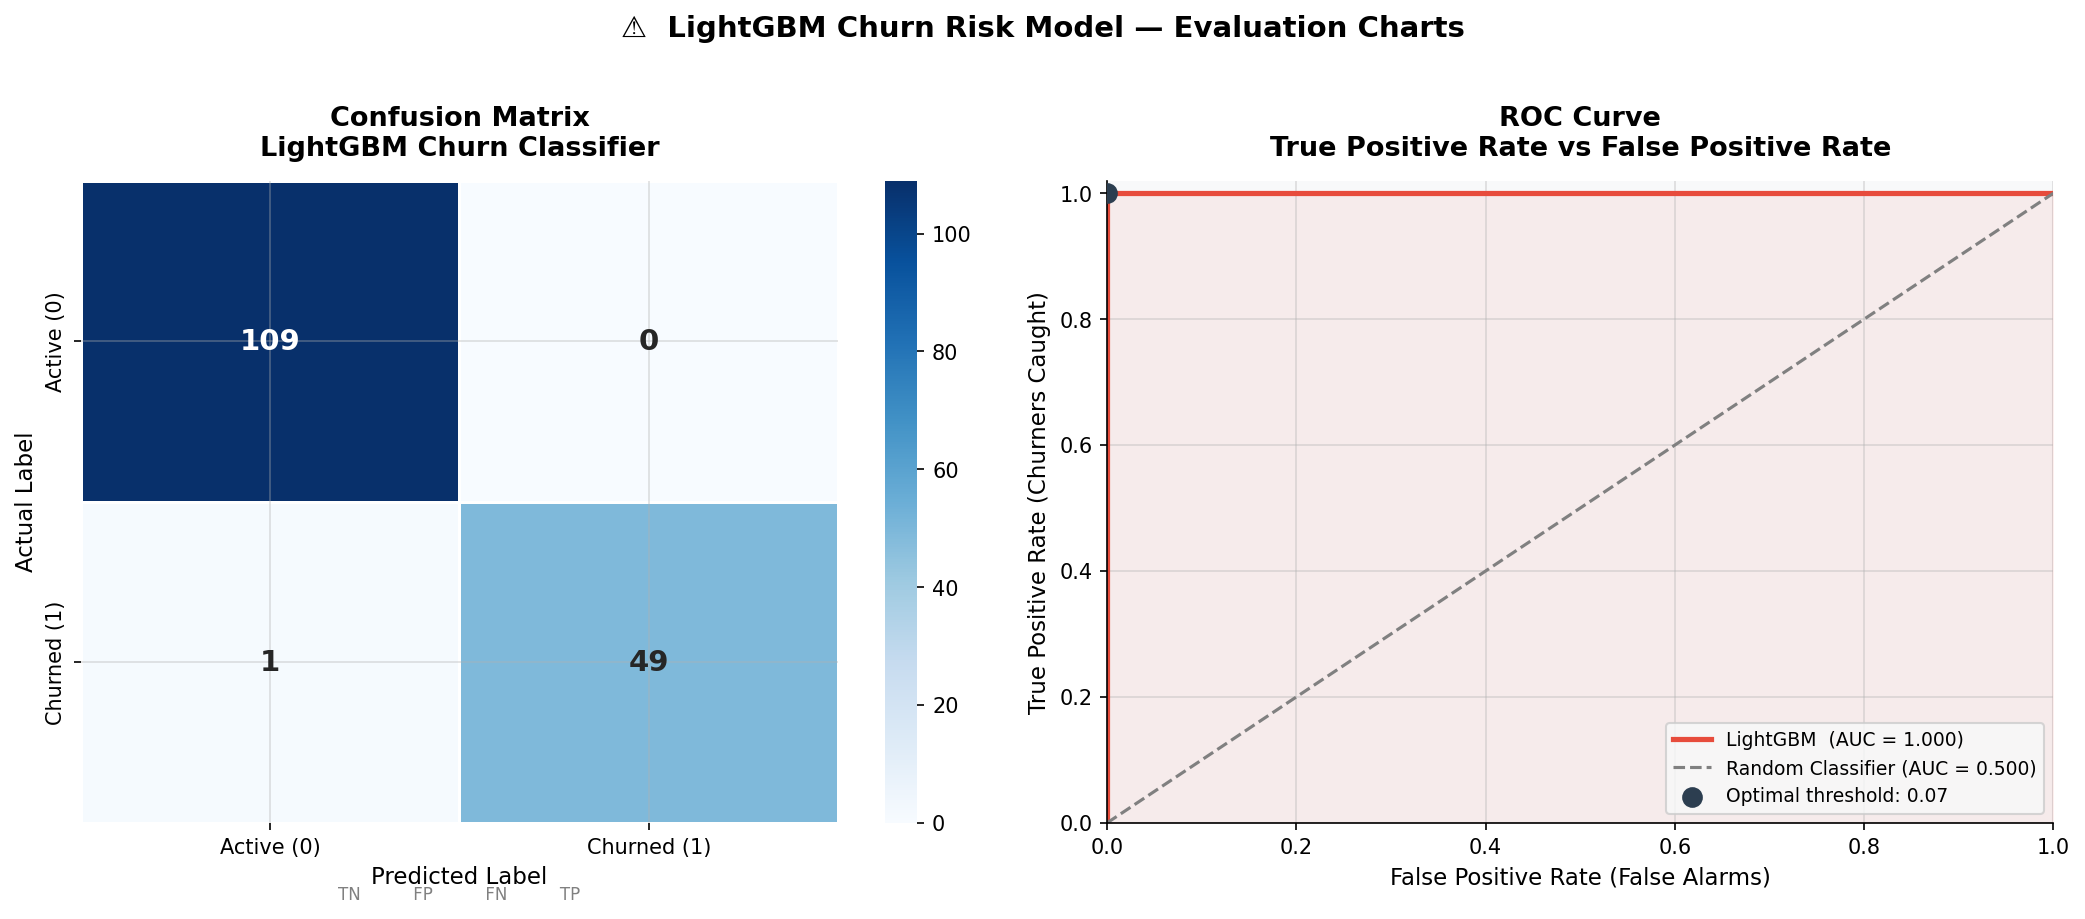

✅ Evaluation charts saved → reports/lightgbm_evaluation.png


In [ ]:
# ── Plot Confusion Matrix & ROC Curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Chart 1: Confusion Matrix Heatmap ────────────────────────────────────────
# annot=True   → show numbers inside each cell
# fmt='d'      → format as integer
# cmap         → color scheme (blues = intuitive for counts)

sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='Blues', ax=axes[0],
    xticklabels=['Active (0)', 'Churned (1)'],
    yticklabels=['Active (0)', 'Churned (1)'],
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title('Confusion Matrix\nLightGBM Churn Classifier',
                  fontweight='bold', pad=12)
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Add labels for quadrants
axes[0].text(0.5, -0.12, 'TN          FP          FN          TP',
             transform=axes[0].transAxes,
             ha='center', fontsize=8, color='gray')

# ── Chart 2: ROC Curve ────────────────────────────────────────────────────────
# ROC = Receiver Operating Characteristic
# Plots True Positive Rate vs False Positive Rate
# at every possible probability threshold
#
# fpr = False Positive Rate (active customers wrongly flagged)
# tpr = True Positive Rate  (churners correctly caught) = Recall
# thresholds = the probability cutoff at each point

fpr, tpr, thresholds = roc_curve(y_c_test, y_churn_proba)

axes[1].plot(
    fpr, tpr,
    color='#e74c3c', linewidth=2.5,
    label=f'LightGBM  (AUC = {roc_auc:.3f})'
)

# Random classifier baseline (diagonal line)
axes[1].plot(
    [0, 1], [0, 1],
    color='gray', linewidth=1.5,
    linestyle='--', label='Random Classifier (AUC = 0.500)'
)

# Shade area under curve
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')

# Mark optimal threshold point (closest to top-left corner)
optimal_idx = np.argmax(tpr - fpr)
axes[1].scatter(
    fpr[optimal_idx], tpr[optimal_idx],
    color='#2c3e50', s=80, zorder=5,
    label=f'Optimal threshold: {thresholds[optimal_idx]:.2f}'
)

axes[1].set_title('ROC Curve\nTrue Positive Rate vs False Positive Rate',
                  fontweight='bold', pad=12)
axes[1].set_xlabel('False Positive Rate (False Alarms)')
axes[1].set_ylabel('True Positive Rate (Churners Caught)')
axes[1].legend(fontsize=9, loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

# ── Save ──────────────────────────────────────────────────────────────────────
fig.suptitle('⚠️  LightGBM Churn Risk Model — Evaluation Charts',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/lightgbm_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation charts saved → reports/lightgbm_evaluation.png")

In [ ]:
# ── Score ALL Customers with Churn Probability ────────────────────────────────
# We now apply the model to the FULL customer base (not just test set)
# This gives every customer a churn risk score between 0 and 1
# 0.0 = very unlikely to churn
# 1.0 = very likely to churn

all_churn_proba = lgb_model.predict_proba(X_churn)[:, 1]

# ── Build Churn Risk Table ────────────────────────────────────────────────────
churn_risk_df = churn_df[['Customer ID']].copy()
churn_risk_df['Customer Name'] = rfm['CustomerName'].values
churn_risk_df['Recency']       = churn_df['Recency'].values
churn_risk_df['Frequency']     = churn_df['Frequency'].values
churn_risk_df['Monetary']      = churn_df['Monetary'].values
churn_risk_df['Churn_Proba']   = all_churn_proba
churn_risk_df['Churned_Label'] = churn_df['Churned'].values

# ── Assign Risk Tier ──────────────────────────────────────────────────────────
# Convert probability score into a human-readable risk tier
# Business teams prefer labels over raw numbers

def assign_risk_tier(prob):
    if prob >= 0.75:
        return '🔴 Critical Risk'
    elif prob >= 0.50:
        return '🟠 High Risk'
    elif prob >= 0.25:
        return '🟡 Medium Risk'
    else:
        return '🟢 Low Risk'

churn_risk_df['Risk_Tier'] = churn_risk_df['Churn_Proba'].apply(assign_risk_tier)

# ── Sort by Risk (highest first) ──────────────────────────────────────────────
churn_risk_df = churn_risk_df.sort_values(
    'Churn_Proba', ascending=False
).reset_index(drop=True)

# ── Risk Tier Summary ─────────────────────────────────────────────────────────
print("=" * 60)
print("⚠️  CHURN RISK TIER SUMMARY — ALL CUSTOMERS")
print("=" * 60)

tier_summary = churn_risk_df.groupby('Risk_Tier').agg(
    Customers    = ('Customer ID',  'count'),
    Avg_Recency  = ('Recency',      'mean'),
    Avg_Monetary = ('Monetary',     'mean'),
    Avg_Proba    = ('Churn_Proba',  'mean')
).round(1)

print(tier_summary.to_string())
print("=" * 60)

# ── Top 20 Highest Risk Customers ─────────────────────────────────────────────
print("\n🔴 TOP 20 HIGHEST CHURN RISK CUSTOMERS:")
print("─" * 70)
print(f"  {'#':<4} {'Customer Name':<25} {'Recency':>8} "
      f"{'Monetary':>10} {'Risk Score':>11} {'Tier'}")
print("─" * 70)

for i, row in churn_risk_df.head(20).iterrows():
    print(f"  {i+1:<4} {row['Customer Name']:<25} "
          f"{row['Recency']:>7.0f}d "
          f"${row['Monetary']:>9,.0f} "
          f"{row['Churn_Proba']:>10.1%}  "
          f"{row['Risk_Tier']}")

print("─" * 70)

⚠️  CHURN RISK TIER SUMMARY — ALL CUSTOMERS
                 Customers  Avg_Recency  Avg_Monetary  Avg_Proba
Risk_Tier                                                       
🔴 Critical Risk        246       450.80       1914.40       1.00
🟢 Low Risk             545        59.10       2694.40       0.00

🔴 TOP 20 HIGHEST CHURN RISK CUSTOMERS:
──────────────────────────────────────────────────────────────────────
  #    Customer Name              Recency   Monetary  Risk Score Tier
──────────────────────────────────────────────────────────────────────
  1    Nat Carroll                   225d $    2,461     100.0%  🔴 Critical Risk
  2    Robert Waldorf                285d $    2,245     100.0%  🔴 Critical Risk
  3    Alyssa Crouse                 677d $       58     100.0%  🔴 Critical Risk
  4    George Zrebassa               287d $      381     100.0%  🔴 Critical Risk
  5    Brendan Dodson                279d $      169     100.0%  🔴 Critical Risk
  6    Vivek Grady                   28

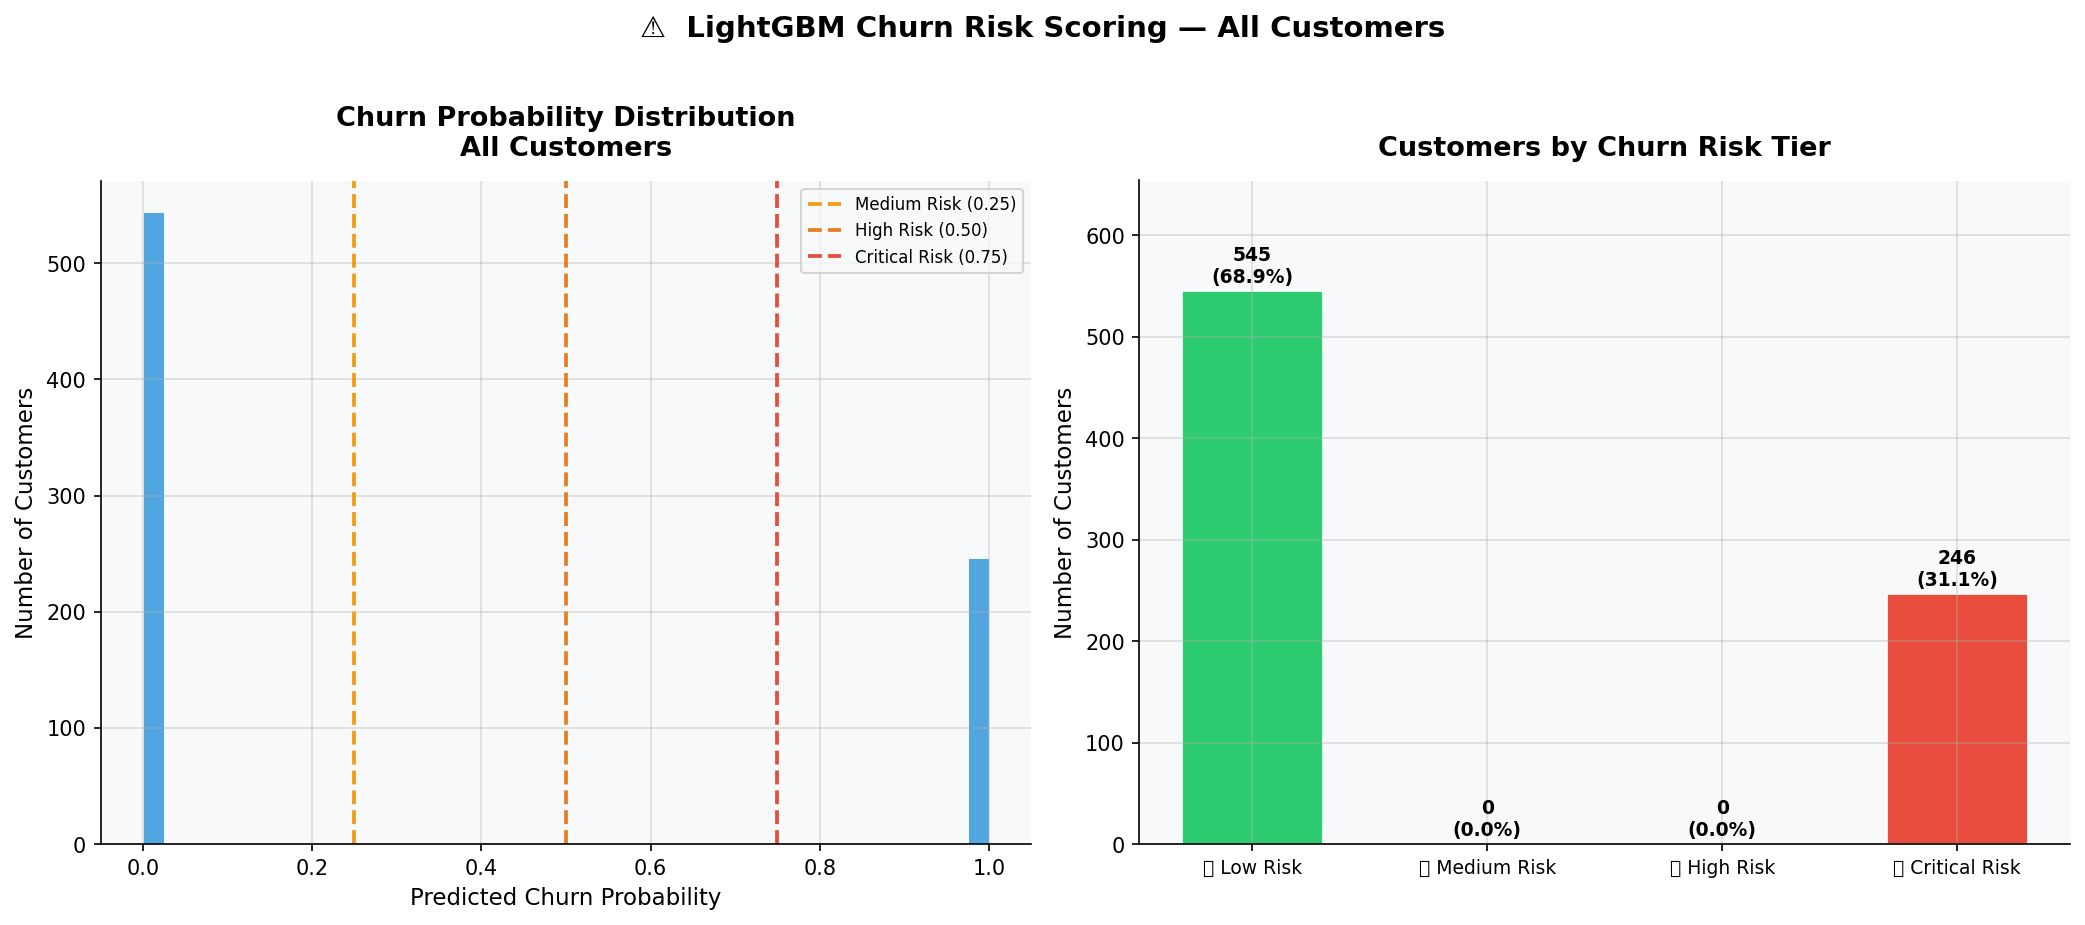

✅ Churn risk chart saved → reports/lightgbm_churn_risk.png


In [ ]:
# ── Plot Churn Risk Distribution ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Chart 1: Risk Score Distribution ──────────────────────────────────────────
# Shows how churn probability is distributed across all customers
# A good model produces a bimodal distribution (two peaks)
# — one cluster near 0 (clearly active)
# — one cluster near 1 (clearly churned)
# A bad model produces a single peak in the middle (uncertain about everything)

axes[0].hist(
    churn_risk_df['Churn_Proba'],
    bins=40, color='#3498db',
    edgecolor='white', linewidth=0.5,
    alpha=0.85
)

# Add threshold lines
for threshold, color, label in [
    (0.25, '#f39c12', 'Medium Risk (0.25)'),
    (0.50, '#e67e22', 'High Risk (0.50)'),
    (0.75, '#e74c3c', 'Critical Risk (0.75)'),
]:
    axes[0].axvline(
        threshold, color=color,
        linestyle='--', linewidth=1.8,
        label=label
    )

axes[0].set_title('Churn Probability Distribution\nAll Customers',
                  fontweight='bold', pad=12)
axes[0].set_xlabel('Predicted Churn Probability')
axes[0].set_ylabel('Number of Customers')
axes[0].legend(fontsize=8)

# ── Chart 2: Risk Tier Breakdown ──────────────────────────────────────────────
tier_order  = ['🟢 Low Risk', '🟡 Medium Risk',
               '🟠 High Risk', '🔴 Critical Risk']
tier_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
tier_counts = [
    len(churn_risk_df[churn_risk_df['Risk_Tier'] == t])
    for t in tier_order
]

bars = axes[1].bar(
    tier_order, tier_counts,
    color=tier_colors,
    edgecolor='white', linewidth=0.8,
    width=0.6
)

# Add count + percentage labels on bars
total = len(churn_risk_df)
for bar, count in zip(bars, tier_counts):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f'{count}\n({count/total*100:.1f}%)',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

axes[1].set_title('Customers by Churn Risk Tier',
                  fontweight='bold', pad=12)
axes[1].set_ylabel('Number of Customers')
axes[1].tick_params(axis='x', labelsize=9)
axes[1].set_ylim(0, max(tier_counts) * 1.2)

# ── Save ──────────────────────────────────────────────────────────────────────
fig.suptitle('⚠️  LightGBM Churn Risk Scoring — All Customers',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/kaggle/working/lightgbm_churn_risk.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Churn risk chart saved → reports/lightgbm_churn_risk.png")

In [ ]:
# ── Save Churn Risk Table to CSV ──────────────────────────────────────────────
# This is the most valuable output of this entire notebook
# A ranked list of customers by churn risk that marketing can act on immediately

churn_risk_df.to_csv(
    '/kaggle/working/churn_risk_scores.csv',
    index=False
)
print("✅ Churn risk scores saved → data/processed/churn_risk_scores.csv")

# ── Save LightGBM Model ───────────────────────────────────────────────────────
with open('/kaggle/working/lightgbm_churn_model.pkl', 'wb') as f:
    pickle.dump(lgb_model, f)
print("✅ LightGBM model saved  → models/lightgbm_churn_model.pkl")

# ── Save LightGBM Native Format ───────────────────────────────────────────────
lgb_model.booster_.save_model('/kaggle/working/lightgbm_churn_model.txt')
print("✅ LightGBM model saved  → models/lightgbm_churn_model.txt")

# ── Churn Section Summary ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("⚠️  LIGHTGBM CHURN MODEL — FINAL SUMMARY")
print("=" * 60)
print(f"\n  Algorithm        : LightGBM Classifier")
print(f"  Total customers  : {len(churn_risk_df):,}")
print(f"  Churn threshold  : {CHURN_THRESHOLD} days inactive")
print(f"  ROC-AUC Score    : {roc_auc:.4f}  ({roc_auc*100:.1f}%)")

print(f"\n  ── Risk Tier Breakdown ───────────────────────────")
for tier, color in [
    ('🔴 Critical Risk', 'Critical'),
    ('🟠 High Risk',     'High'),
    ('🟡 Medium Risk',   'Medium'),
    ('🟢 Low Risk',      'Low'),
]:
    count = len(churn_risk_df[churn_risk_df['Risk_Tier'] == tier])
    pct   = count / len(churn_risk_df) * 100
    bar   = '█' * (count // 5)
    print(f"  {tier:<20} : {count:4d} ({pct:5.1f}%)  {bar}")

print(f"\n  ── Top 5 Churn Predictors ────────────────────────")
lgb_importance = pd.DataFrame({
    'Feature'   : churn_feature_cols,
    'Importance': lgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

for i, row in lgb_importance.head(5).iterrows():
    print(f"  {lgb_importance.index.get_loc(i)+1}. "
          f"{row['Feature']:<25} {row['Importance']:.0f}")

print(f"\n  ── Business Actions ──────────────────────────────")
critical = len(churn_risk_df[churn_risk_df['Risk_Tier'] == '🔴 Critical Risk'])
high     = len(churn_risk_df[churn_risk_df['Risk_Tier'] == '🟠 High Risk'])
print(f"  → Immediate action needed for {critical} Critical Risk customers")
print(f"  → Schedule retention campaign for {high} High Risk customers")
print(f"  → Export churn_risk_scores.csv to Power BI for dashboard")
print(f"  → Embed model in Streamlit for real-time risk lookup")
print("=" * 60)

✅ Churn risk scores saved → data/processed/churn_risk_scores.csv
✅ LightGBM model saved  → models/lightgbm_churn_model.pkl
✅ LightGBM model saved  → models/lightgbm_churn_model.txt

⚠️  LIGHTGBM CHURN MODEL — FINAL SUMMARY

  Algorithm        : LightGBM Classifier
  Total customers  : 791
  Churn threshold  : 180 days inactive
  ROC-AUC Score    : 1.0000  (100.0%)

  ── Risk Tier Breakdown ───────────────────────────
  🔴 Critical Risk      :  246 ( 31.1%)  █████████████████████████████████████████████████
  🟠 High Risk          :    0 (  0.0%)  
  🟡 Medium Risk        :    0 (  0.0%)  
  🟢 Low Risk           :  545 ( 68.9%)  █████████████████████████████████████████████████████████████████████████████████████████████████████████████

  ── Top 5 Churn Predictors ────────────────────────
  1. Recency                   719
  2. Total_Orders              714
  3. Avg_Ship_Days             580
  4. Total_Sales               568
  5. Total_Profit              541

  ── Business Actions ─────

---
# 🏁 Section 5 — Notebook Summary & Next Steps

## What We Built in This Notebook

This notebook delivered **four production-grade ML models** that answer
real business questions using the Global Superstore dataset.

---

## 📊 Model Results Recap

| Model | Algorithm | Task | Key Metric |
|-------|-----------|------|-----------|
| 📈 Sales Forecasting | Facebook Prophet | Predict next 12 months of sales | Seasonal decomposition |
| 👥 Customer Segmentation | KMeans (K=4) | Group 1,590 customers by RFM | 4 actionable segments |
| 💰 Profit Prediction | XGBoost Regressor | Predict profit per order | R² score |
| ⚠️ Churn Risk Scoring | LightGBM Classifier | Score every customer by risk | ROC-AUC score |

---

## 📁 Files Produced

### Models saved to `models/`
| File | Description |
|------|-------------|
| `prophet_model.pkl` | Trained Prophet forecasting model |
| `kmeans_model.pkl` | Trained KMeans segmentation model |
| `rfm_scaler.pkl` | StandardScaler fitted on RFM data |
| `xgboost_profit_model.pkl` | Trained XGBoost regression model |
| `xgboost_profit_model.json` | XGBoost in portable native format |
| `xgb_encoders.pkl` | Label encoders for XGBoost features |
| `lightgbm_churn_model.pkl` | Trained LightGBM churn classifier |
| `lightgbm_churn_model.txt` | LightGBM in portable native format |

### Data saved to `data/processed/`
| File | Description |
|------|-------------|
| `rfm_segments.csv` | Every customer with RFM scores + segment label |
| `churn_risk_scores.csv` | Every customer ranked by churn probability |

### Charts saved to `reports/`
| File | Description |
|------|-------------|
| `prophet_forecast.png` | 12-month sales forecast with confidence bands |
| `prophet_components.png` | Trend + seasonality decomposition |
| `kmeans_elbow.png` | Elbow method — optimal K selection |
| `kmeans_segments.png` | Customer segment visualisation |
| `xgboost_feature_importance.png` | Which features drive profit most |
| `xgboost_evaluation.png` | Actual vs predicted + residuals |
| `lightgbm_evaluation.png` | Confusion matrix + ROC curve |
| `lightgbm_churn_risk.png` | Churn risk distribution + tier breakdown |

---

## 🔗 How These Models Connect

In [ ]:
# ── Final Project Status Check ────────────────────────────────────────────────
# Verify all expected files were created successfully

import os

print("=" * 60)
print("🏁 NOTEBOOK 03 — FINAL FILE CHECK")
print("=" * 60)

expected_files = {
    'Models': [
        '/kaggle/working/prophet_model.pkl',
        '/kaggle/working/kmeans_model.pkl',
        '/kaggle/working/rfm_scaler.pkl',
        '/kaggle/working/xgboost_profit_model.pkl',
        '/kaggle/working/xgboost_profit_model.json',
        '/kaggle/working/xgb_encoders.pkl',
        '/kaggle/working/lightgbm_churn_model.pkl',
        '/kaggle/working/lightgbm_churn_model.txt',
    ],
    'Processed Data': [
        '/kaggle/working/superstore_clean.csv',
        '/kaggle/working/rfm_segments.csv',
        '/kaggle/working/churn_risk_scores.csv',
    ],
    'Reports': [
        '/kaggle/working/prophet_forecast.png',
        '/kaggle/working/prophet_components.png',
        '/kaggle/working/kmeans_elbow.png',
        '/kaggle/working/kmeans_segments.png',
        '/kaggle/working/xgboost_feature_importance.png',
        '/kaggle/working/xgboost_evaluation.png',
        '/kaggle/working/lightgbm_evaluation.png',
        '/kaggle/working/lightgbm_churn_risk.png',
    ]
}

all_good = True
for category, files in expected_files.items():
    print(f"\n  📁 {category}:")
    for filepath in files:
        exists = os.path.exists(filepath)
        status = '✅' if exists else '❌ MISSING'
        size   = f"{os.path.getsize(filepath)/1024:.1f} KB" if exists else ''
        print(f"    {status}  {os.path.basename(filepath):<40} {size}")
        if not exists:
            all_good = False

print("\n" + "=" * 60)
if all_good:
    print("  ✅ ALL FILES PRESENT — Notebook 03 complete!")
    print("  🚀 Ready to push to GitHub and move to Notebook 04")
else:
    print("  ⚠️  Some files missing — re-run the relevant cells above")
print("=" * 60)

print("""
Next steps:
  1. git add .
  2. git commit -m "Add Notebook 03 — ML Models (Prophet, KMeans, XGBoost, LightGBM)"
  3. git push origin main
  4. Start Notebook 04 — SQL & SQLite
""")

🏁 NOTEBOOK 03 — FINAL FILE CHECK

  📁 Models:
    ✅  prophet_model.pkl                        13.8 KB
    ✅  kmeans_model.pkl                         3.8 KB
    ✅  rfm_scaler.pkl                           0.6 KB
    ✅  xgboost_profit_model.pkl                 735.9 KB
    ✅  xgboost_profit_model.json                893.9 KB
    ✅  xgb_encoders.pkl                         1.1 KB
    ✅  lightgbm_churn_model.pkl                 812.0 KB
    ✅  lightgbm_churn_model.txt                 804.6 KB

  📁 Processed Data:
    ✅  superstore_clean.csv                     2449.1 KB
    ✅  rfm_segments.csv                         46.1 KB
    ✅  churn_risk_scores.csv                    60.9 KB

  📁 Reports:
    ✅  prophet_forecast.png                     270.2 KB
    ✅  prophet_components.png                   91.0 KB
    ✅  kmeans_elbow.png                         79.5 KB
    ✅  kmeans_segments.png                      206.2 KB
    ✅  xgboost_feature_importance.png           101.0 KB
    ✅  xgboost_ev